# Trajectory aggregation, step by step

This notebook re-does what `d4rt_agent/sam_orientany_d4rt_test` does *after* the models have
run — no SAM3, no Orient-Anything, no D4RT forward pass. Everything below reads the arrays this
run already wrote to disk and rebuilds the analysis by hand, plotting the state after every step.

The pipeline that produced the inputs:

```
text phrase ──SAM3──▶ per-frame masks ──┬──▶ 20 seed points ──D4RT──▶ 3D tracks (P=20, T=32)
                                        └──▶ 12×12 image grid ──D4RT──▶ camera-recovery cloud
```

What this notebook rebuilds (mirrors `traj3d_analyze.py` + `traj3d_geometry.py`):

| Step | What happens | Where it lives in the pipeline |
|---|---|---|
| 1 | logits → probabilities, gate on visibility/confidence | `sigmoid`, `build_trajectory` |
| 2 | look at the 20 raw 3D tracks | — |
| 3 | **RANSAC** over Kabsch → per-frame camera pose | `robust_rigid`, `recover_camera_poses` |
| 4 | reject whole bad tracks (3 tests) | `select_tracks` |
| 5 | **median** — weighted geometric median per frame | `geometric_median`, `aggregate_trajectory` |
| 6 | Savitzky–Golay smoothing | `smooth_trajectory` |
| 7 | **post-processing** — running mean, then drop axes that only carry noise | *(not in the pipeline)* |
| 8 | check the rebuild against the pipeline's own output | — |
| 9 | **camera-to-subject separation** over time | *(not in the pipeline)* |

One clip at a time: pick it with `VIDEO` in the setup cell and *Run All*. The appendix at the
bottom can repeat the analysis for the other clips, but it is off unless you ask for it.

Panels that belong to one group — the X, Y and Z of the same quantity — are drawn on a **single
locked scale** via `lock_axes`, never autoscaled individually. Independently scaled panels make an
axis carrying 0.1 units look exactly as busy as one carrying 1.7, which is the fastest way to
misread this data. Where a panel sits outside the group (a step length, an inlier count) it keeps
its own scale, and rows for the subject and the camera are locked separately because their
magnitudes differ by roughly a hundredfold.

Two different things are called "RANSAC" here, and they are worth keeping apart:

* **Step 3** is real RANSAC — random 3-point minimal samples, consensus scoring — used to fit the
  camera's rigid motion from the 144-point grid.
* **Step 5**'s output column is *named* `ransac_median`, but it is not RANSAC. The outlier
  rejection happened once, at track level, in step 4; step 5 is the weighted geometric median of
  whatever survived. The name is historical.

## Setup — pick the clip here

Pure NumPy + Matplotlib; nothing below needs a GPU or a model checkpoint.

**`VIDEO` in the next cell is the only knob.** Set it, *Run All*, and every step from here to the
end runs on that one clip. Running the cell prints the clips found in this run directory, so on a
first pass just run it, read the list, change the number and run again.

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from PIL import Image

warnings.filterwarnings("ignore", category=RuntimeWarning)   # nanmedian over all-NaN slices
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

def lock_axes(axes, x=True, y=True, pad=0.05):
    """Give a group of panels ONE common scale.

    Panels that each autoscale are easy to misread: an axis carrying 0.1 units of motion and one
    carrying 1.7 are drawn the same height, so they look equally important.  Locking the group to
    a shared range makes the comparison honest -- a small axis is *drawn* small.
    """
    axes = list(np.ravel(axes))
    if y:
        lo = min(a.get_ylim()[0] for a in axes); hi = max(a.get_ylim()[1] for a in axes)
        m = pad * max(hi - lo, 1e-9)
        for a in axes: a.set_ylim(lo - m, hi + m)
    if x:
        lo = min(a.get_xlim()[0] for a in axes); hi = max(a.get_xlim()[1] for a in axes)
        for a in axes: a.set_xlim(lo, hi)
    return axes


# Locate the run.  This notebook lives next to the pipeline it explains, not inside a run
# directory, so the path is resolved rather than hard-coded: set RUN_DIR to override.
RUN_NAME = "traj3d_a100_20260819T100744Z"        # the run these saved outputs came from
RUN_DIR  = None

if RUN_DIR is None:
    here = Path.cwd()
    if (here / "run_metadata.json").exists():                     # started inside a run dir
        RUN_DIR = here
    else:
        root = next((q for q in [here, *here.parents]
                     if (q / "d4rt_agent" / "results").is_dir()), None)
        results = (root / "d4rt_agent" / "results") if root else None
        if results is not None and (results / RUN_NAME).is_dir():
            RUN_DIR = results / RUN_NAME
        elif results is not None and sorted(results.glob("traj3d_*")):
            RUN_DIR = sorted(results.glob("traj3d_*"))[-1]         # fall back to the newest run
        else:
            raise SystemExit("no run directory found -- set RUN_DIR above by hand")
RUN_DIR = Path(RUN_DIR)
print(f"run: {RUN_DIR}")

VIDEOS = sorted(p.name for p in RUN_DIR.iterdir() if p.is_dir())

# ===========================================================================
#  SELECT THE CLIP  --  every step in this notebook runs on this one
# ===========================================================================
VIDEO = 1

# Optional appendix at the very bottom: re-run the whole analysis for the other
# clips too, purely to compare the three side by side.  Off by default.
COMPARE_ALL = False
# ===========================================================================

VIDEO = int(VIDEO) % len(VIDEOS)
for i, v in enumerate(VIDEOS):
    subject = json.loads((RUN_DIR / v / "analysis" / "summary.json").read_text())["subject"]
    print(f"{'-->' if i == VIDEO else '   '} [{i}] {subject!r}\n        {v}")

run: /cluster/work/igp_psr/spanwar/Open-d4rt/d4rt_agent/results/traj3d_a100_20260819T100744Z
    [0] 'the person in the yellow jacket'
        656086265ccda299e2c2ec394f4bfded4daa3ea64efcb4ee6c95b8c7de.0_95469228
--> [1] 'the runner'
        camerabench_m0jmssq5ptw.3.12_ccd85243
    [2] 'the character in pink'
        synfmc_rendered_traj_results_dynamic_6_video_480p_728b5ef1


In [2]:
# Everything the selected clip wrote to disk.  Re-run from here after changing VIDEO.
SLUG = VIDEOS[VIDEO]
VD = RUN_DIR / SLUG

subject_npz = dict(np.load(VD / "d4rt" / "subject.npz"))   # the 20 tracked points
camera_npz  = dict(np.load(VD / "d4rt" / "camera.npz"))    # the 12x12 camera-recovery grid
points      = json.loads((VD / "points.json").read_text())
seg         = json.loads((VD / "segmentation.json").read_text())
summary     = json.loads((VD / "analysis" / "summary.json").read_text())

FRAMES = sorted((VD / "frames").glob("*.jpg"))
H, W = points["height"], points["width"]
P, T = subject_npz["xyz_3d"].shape[:2]

print(f"{SLUG}\n  subject : {summary['subject']!r}\n  frames  : {T}  ({W}x{H})")
print(f"  seeded  : {P} subject points on frame {points['seed_frame']}, "
      f"{len(points['camera_grid_px'])} grid points for camera recovery")
print("\narrays on disk:")
for name, d in (("subject.npz", subject_npz), ("camera.npz", camera_npz)):
    print(f"  {name:12s}", {k: tuple(v.shape) for k, v in d.items()})

camerabench_m0jmssq5ptw.3.12_ccd85243
  subject : 'the runner'
  frames  : 32  (480x270)
  seeded  : 20 subject points on frame 31, 144 grid points for camera recovery

arrays on disk:
  subject.npz  {'xyz_3d': (20, 32, 3), 'uv_2d': (20, 32, 2), 'visibility': (20, 32), 'displacement': (20, 32, 3), 'normal': (20, 32, 3), 'confidence': (20, 32)}
  camera.npz   {'xyz_3d': (32, 144, 3), 'uv_2d': (32, 144, 2), 'visibility': (32, 144), 'displacement': (32, 144, 3), 'normal': (32, 144, 3), 'confidence': (32, 144)}


## Step 0 — what the models handed over

Two point sets, both queried through D4RT:

* **subject points** — 20 pixels sampled inside SAM3's mask on the seed frame, tracked in 3D
  across all 32 frames. Shape `(P=20, T=32, 3)`.
* **camera grid** — a plain 12×12 grid over the whole image, queried at `t_tgt=0` from every
  viewpoint `t_cam`. Shape `(T=32, 144, 3)`. Same world geometry seen from 32 camera poses, so the
  frames differ by exactly the camera's rigid motion — which is what step 3 recovers.

Before trusting anything downstream, look at whether SAM3 grabbed the right thing.

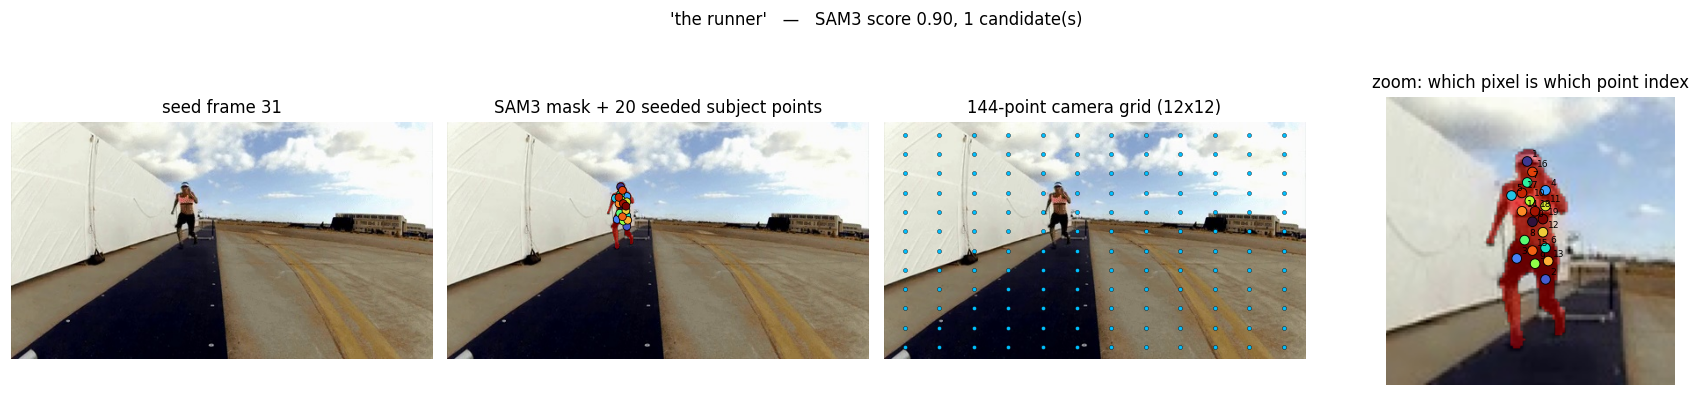

In [3]:
seed_t = points["seed_frame"]
seed_img = np.asarray(Image.open(FRAMES[seed_t]))
masks = np.load(VD / "masks" / "masks.npy")
subj_px = np.asarray(points["subject_points_px"])
grid_px = np.asarray(points["camera_grid_px"])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
axes[0].imshow(seed_img); axes[0].set_title(f"seed frame {seed_t}")

axes[1].imshow(seed_img)
axes[1].imshow(np.ma.masked_where(~masks[seed_t].astype(bool), masks[seed_t]),
               cmap="autumn", alpha=0.45)
axes[1].scatter(subj_px[:, 0], subj_px[:, 1], s=26, c=np.arange(P), cmap="turbo",
                edgecolors="black", linewidths=0.5, zorder=3)
axes[1].set_title(f"SAM3 mask + {P} seeded subject points")

axes[2].imshow(seed_img)
axes[2].scatter(grid_px[:, 0], grid_px[:, 1], s=7, c="deepskyblue", edgecolors="black",
                linewidths=0.25)
axes[2].set_title(f"{len(grid_px)}-point camera grid (12x12)")

ys, xs = np.nonzero(masks[seed_t].astype(bool))          # zoom, because the subject can be tiny
pad_px = 0.6 * max(xs.ptp(), ys.ptp()) + 10
x0, x1 = max(xs.mean() - pad_px, 0), min(xs.mean() + pad_px, W)
y0, y1 = max(ys.mean() - pad_px, 0), min(ys.mean() + pad_px, H)
axes[3].imshow(seed_img)
axes[3].imshow(np.ma.masked_where(~masks[seed_t].astype(bool), masks[seed_t]), cmap="autumn", alpha=0.4)
axes[3].scatter(subj_px[:, 0], subj_px[:, 1], s=40, c=np.arange(P), cmap="turbo",
                edgecolors="black", linewidths=0.6)
for i, (u, v) in enumerate(subj_px):
    axes[3].annotate(str(i), (u, v), fontsize=6, xytext=(3, 3), textcoords="offset points")
axes[3].set_xlim(x0, x1); axes[3].set_ylim(y1, y0)
axes[3].set_title("zoom: which pixel is which point index")

for ax in axes: ax.axis("off")
fig.suptitle(f"{summary['subject']!r}   —   SAM3 score {seg['chosen_score']:.2f}, "
             f"{len(seg['candidate_boxes_xyxy'])} candidate(s)", y=1.04)
plt.tight_layout(); plt.show()

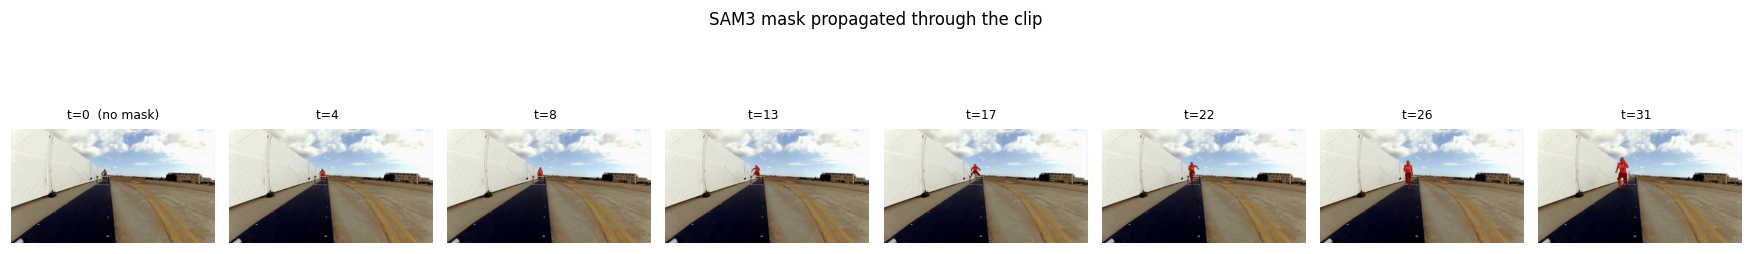

In [4]:
# The mask across time -- if SAM3 loses the subject, the tracks that follow are meaningless.
show = np.linspace(0, T - 1, 8).astype(int)
fig, axes = plt.subplots(1, len(show), figsize=(16, 2.4))
for ax, t in zip(axes, show):
    img = np.asarray(Image.open(FRAMES[t]))
    ax.imshow(img)
    m = masks[t].astype(bool)
    if m.any():
        ax.imshow(np.ma.masked_where(~m, m.astype(float)), cmap="autumn", alpha=0.45)
    ax.set_title(f"t={t}  {'' if m.any() else '(no mask)'}", fontsize=8)
    ax.axis("off")
fig.suptitle("SAM3 mask propagated through the clip", y=1.10)
plt.tight_layout(); plt.show()

## Step 1 — logits → probabilities, then gate

`visibility` and `confidence` come out of D4RT as **raw logits**: the query path used by this
pipeline sits below the layer that applies the sigmoid (`src/model/heads.py:16,19` are bare
`nn.Linear`). Thresholding them directly at 0.5 would keep essentially everything — note the
logit range printed below.

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

Gate: keep a `(point, frame)` sample when it is finite **and** `σ(visibility) > 0.5` **and**
`σ(confidence) > 0.2`. The confidence cut comes from the training objective
$c\,e - 0.2\log c$, minimised at $c = 0.2/e$ — so $c = 0.2$ is "predicted error of order the
scene depth". Weight for the later median is $\sigma(\text{confidence})^2$.

In [5]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=np.float64)))

VISIBILITY_THRESHOLD = 0.5
CONFIDENCE_THRESHOLD = 0.2

xyz        = subject_npz["xyz_3d"].astype(np.float64)      # (P, T, 3), OpenCV camera frame of t=0
uv         = subject_npz["uv_2d"].astype(np.float64)       # (P, T, 2), normalised 0..1
visibility = sigmoid(subject_npz["visibility"])            # (P, T)
confidence = sigmoid(subject_npz["confidence"])            # (P, T)

valid   = (np.isfinite(xyz).all(axis=-1)
           & (visibility > VISIBILITY_THRESHOLD)
           & (confidence > CONFIDENCE_THRESHOLD))
weights = confidence ** 2

print(f"raw logits   visibility [{subject_npz['visibility'].min():7.2f}, {subject_npz['visibility'].max():7.2f}]"
      f"   confidence [{subject_npz['confidence'].min():7.2f}, {subject_npz['confidence'].max():7.2f}]")
print(f"probabilities visibility [{visibility.min():.3f}, {visibility.max():.3f}]"
      f"   confidence [{confidence.min():.3f}, {confidence.max():.3f}]")
print(f"\nsamples kept by the gate: {valid.sum()} / {valid.size} "
      f"({100*valid.mean():.1f}%)   -- if this is ~100%, the gate is not doing much on this clip")

raw logits   visibility [   1.35,   11.25]   confidence [   9.75,   11.31]
probabilities visibility [0.794, 1.000]   confidence [1.000, 1.000]

samples kept by the gate: 640 / 640 (100.0%)   -- if this is ~100%, the gate is not doing much on this clip


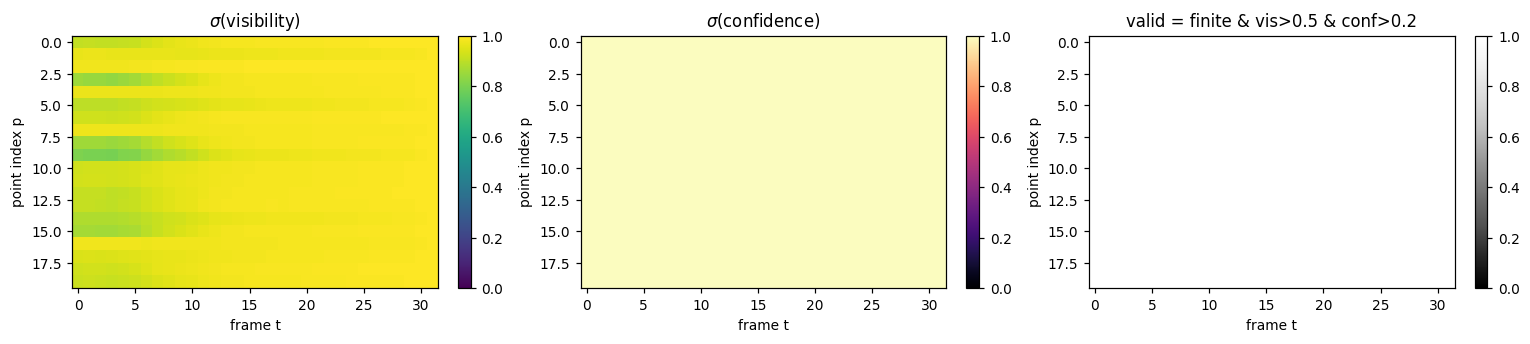

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
for ax, (arr, title, kw) in zip(axes, [
        (visibility, r"$\sigma$(visibility)", dict(cmap="viridis", vmin=0, vmax=1)),
        (confidence, r"$\sigma$(confidence)", dict(cmap="magma", vmin=0, vmax=1)),
        (valid.astype(float), "valid = finite & vis>0.5 & conf>0.2", dict(cmap="Greys_r", vmin=0, vmax=1))]):
    im = ax.imshow(arr, aspect="auto", interpolation="nearest", **kw)
    ax.set_title(title); ax.set_xlabel("frame t"); ax.set_ylabel("point index p")
    ax.grid(False); fig.colorbar(im, ax=ax, fraction=0.035)
plt.tight_layout(); plt.show()

## Step 2 — the 20 raw 3D tracks

This is the input to everything that follows: 20 independent 3D trajectories, one per seeded
pixel. They are in D4RT's camera frame at `t=0` — **+x right, +y down, +z forward** — and the
units are arbitrary (the training loss normalises each clip by its own mean depth). That is why
every threshold later is a multiple of the clip's own scale rather than a distance in metres.

The spread between these 20 curves is the thing steps 4–6 exist to collapse. Look at it before it
gets averaged away.

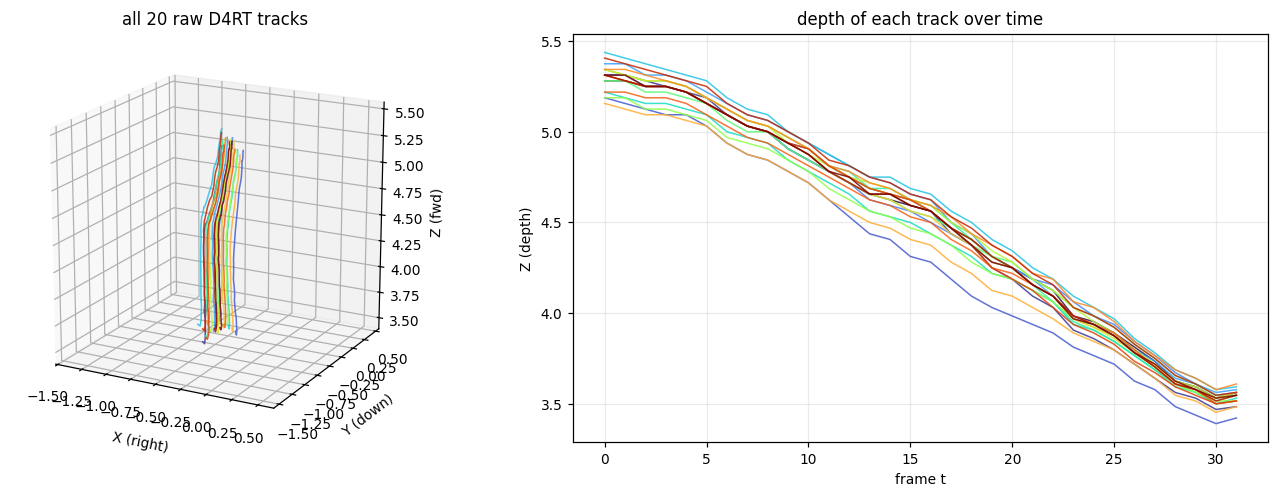

In [7]:
def equalise_3d(ax, pts):
    """Cubic bounding box -- matplotlib stretches 3D axes independently and distorts shape."""
    f = pts[np.isfinite(pts).all(axis=1)]
    if f.size == 0: return
    c, r = f.mean(axis=0), max(float(np.max(np.abs(f - f.mean(axis=0)))), 1e-6)
    ax.set_xlim(c[0]-r, c[0]+r); ax.set_ylim(c[1]-r, c[1]+r); ax.set_zlim(c[2]-r, c[2]+r)
    ax.set_box_aspect((1, 1, 1))

masked = np.where(valid[..., None], xyz, np.nan)           # (P, T, 3) with gated-out samples as NaN

fig = plt.figure(figsize=(13, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
cmap = plt.get_cmap("turbo")
for p in range(P):
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() > 1:
        ax.plot(*masked[p, ok].T, color=cmap(p / (P - 1)), lw=1.0, alpha=0.85)
ax.set_xlabel("X (right)"); ax.set_ylabel("Y (down)"); ax.set_zlabel("Z (fwd)")
ax.set_title(f"all {P} raw D4RT tracks"); ax.view_init(elev=18, azim=-62)
equalise_3d(ax, masked.reshape(-1, 3))

ax2 = fig.add_subplot(1, 2, 2)
for p in range(P):
    ax2.plot(masked[p, :, 2], color=cmap(p / (P - 1)), lw=1.0, alpha=0.85)
ax2.set_xlabel("frame t"); ax2.set_ylabel("Z (depth)"); ax2.set_title("depth of each track over time")
plt.tight_layout(); plt.show()

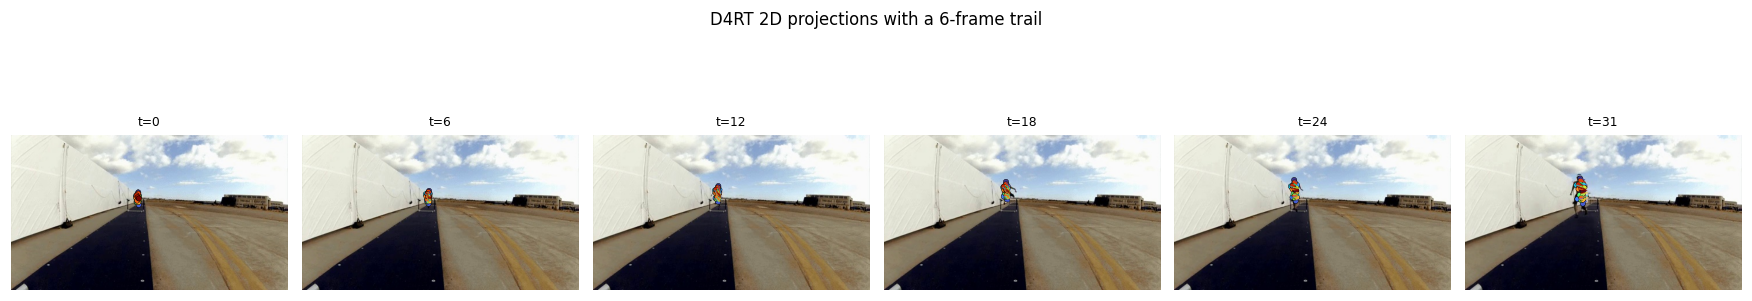

In [8]:
# The same tracks back in image space -- the honest check that they are stuck to the subject.
show = np.linspace(0, T - 1, 6).astype(int)
fig, axes = plt.subplots(1, len(show), figsize=(16, 2.9))
for ax, t in zip(axes, show):
    ax.imshow(np.asarray(Image.open(FRAMES[t])))
    for p in range(P):
        trail = uv[p, max(0, t - 6):t + 1] * [W - 1, H - 1]
        ax.plot(trail[:, 0], trail[:, 1], color=cmap(p / (P - 1)), lw=0.8, alpha=0.7)
    pts = uv[:, t] * [W - 1, H - 1]
    ax.scatter(pts[valid[:, t], 0], pts[valid[:, t], 1], s=12, c=np.arange(P)[valid[:, t]],
               cmap="turbo", vmin=0, vmax=P - 1, edgecolors="black", linewidths=0.3)
    ax.set_title(f"t={t}", fontsize=8); ax.axis("off")
fig.suptitle("D4RT 2D projections with a 6-frame trail", y=1.08)
plt.tight_layout(); plt.show()

## Step 3 — RANSAC over Kabsch: recovering the camera

`camera.npz` holds the **same** 144 world points (`t_tgt = 0`) as seen from each of the 32
viewpoints. Since both views describe identical geometry, they differ by exactly the camera's
rigid motion:

$$X_0 = T_{cw}[0]\,p_{world}, \qquad X_t = T_{cw}[t]\,p_{world}
\;\Longrightarrow\; X_0 = T_{cw}[0]\,T_{cw}[t]^{-1} X_t$$

$p_{world}$ cancels — which is why the grid points do **not** need to be static, or even off the
subject. A plain uniform grid is correct.

So for each frame we want the rigid transform $(R, t)$ with $X_0 \approx R X_t + t$.

**Kabsch** solves that in closed form for a given correspondence set (SVD of the cross-covariance,
with the reflection fix). **RANSAC** wraps it because a handful of grid points land on moving
objects or on depth discontinuities where D4RT is simply wrong, and least squares has breakdown
point 0 — one bad point drags the whole fit.

The loop: 1000 times, pick 3 points at random, fit, count how many of the other points land within
`threshold = 0.05 × cloud_scale` of their prediction, keep the largest consensus set — then refit
on it. The threshold is a fraction of the cloud's own scale, never an absolute distance.

In [9]:
def kabsch(src, dst):
    """Least-squares rigid transform with dst ~= R @ src + t.  Returns None if degenerate."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    if src.shape != dst.shape or src.ndim != 2 or src.shape[1] != 3 or src.shape[0] < 3:
        return None
    mu_s, mu_d = src.mean(0), dst.mean(0)
    cov = ((src - mu_s).T @ (dst - mu_d)) / len(src)
    u, _, vt = np.linalg.svd(cov)
    R = vt.T @ u.T
    if np.linalg.det(R) < 0:                 # reflection fix: flip the smallest singular direction
        vt[-1] *= -1.0
        R = vt.T @ u.T
    t = mu_d - R @ mu_s
    return (R, t) if np.isfinite(R).all() and np.isfinite(t).all() else None


def cloud_scale(pts):
    """Median radius of a cloud about its median.  Every threshold below is a multiple of this."""
    pts = np.asarray(pts, float).reshape(-1, 3)
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) == 0: return float("nan")
    return float(np.median(np.linalg.norm(pts - np.median(pts, axis=0), axis=1)))


def sim3_scale(src, dst):
    """Scale of the best similarity fit -- should come out ~1.0 if rigid is the right model."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    var = float(((src - src.mean(0)) ** 2).sum() / max(len(src), 1))
    if var <= 1e-12: return float("nan")
    cov = ((src - src.mean(0)).T @ (dst - dst.mean(0))) / len(src)
    u, s, vt = np.linalg.svd(cov)
    d = np.ones(3)
    if np.linalg.det(vt.T @ u.T) < 0: d[-1] = -1.0
    return float((s * d).sum() / var)


def ransac_rigid(src, dst, weights=None, threshold_ratio=0.05, iterations=1000, seed=0, trace=False):
    """RANSAC over Kabsch.  Same sampling order as traj3d_geometry.robust_rigid, so it reproduces it."""
    src, dst = np.asarray(src, float), np.asarray(dst, float)
    ok = np.isfinite(src).all(1) & np.isfinite(dst).all(1)
    if weights is not None:
        ok &= np.asarray(weights, float) > 0
    if ok.sum() < 3: return None

    idx = np.flatnonzero(ok)
    scale = cloud_scale(dst[idx])
    if not np.isfinite(scale) or scale <= 0: return None
    threshold = threshold_ratio * scale

    rng = np.random.default_rng(seed)
    best_inliers, best_count, history = None, -1, []
    for _ in range(iterations):
        pick = rng.choice(idx, size=3, replace=False)
        fit = kabsch(src[pick], dst[pick])
        if fit is None:
            history.append(best_count); continue
        R, t = fit
        residual = np.linalg.norm((src[idx] @ R.T + t) - dst[idx], axis=1)
        inliers = residual < threshold
        if inliers.sum() > best_count:
            best_count, best_inliers = int(inliers.sum()), idx[inliers]
        history.append(best_count)

    if best_inliers is None or best_inliers.size < 3: return None
    R, t = kabsch(src[best_inliers], dst[best_inliers])          # refit on the consensus set

    residual_all = np.linalg.norm((src @ R.T + t) - dst, axis=1)
    mask = np.zeros(len(src), bool); mask[best_inliers] = True
    centred = src[best_inliers] - src[best_inliers].mean(0)
    sv = np.linalg.svd(centred, compute_uv=False)

    out = dict(rotation=R, translation=t, inliers=mask,
               rmse=float(np.sqrt(np.mean(residual_all[mask] ** 2))),
               scale=sim3_scale(src[best_inliers], dst[best_inliers]),
               conditioning=float(sv[2] / max(sv[0], 1e-12)),
               threshold=threshold, residual=residual_all)
    if trace: out["history"] = np.array(history)
    return out

frame 16: 143/144 inliers, threshold 0.0687 (= 0.05 x cloud scale), rmse 0.0177, sim3 scale 0.9993


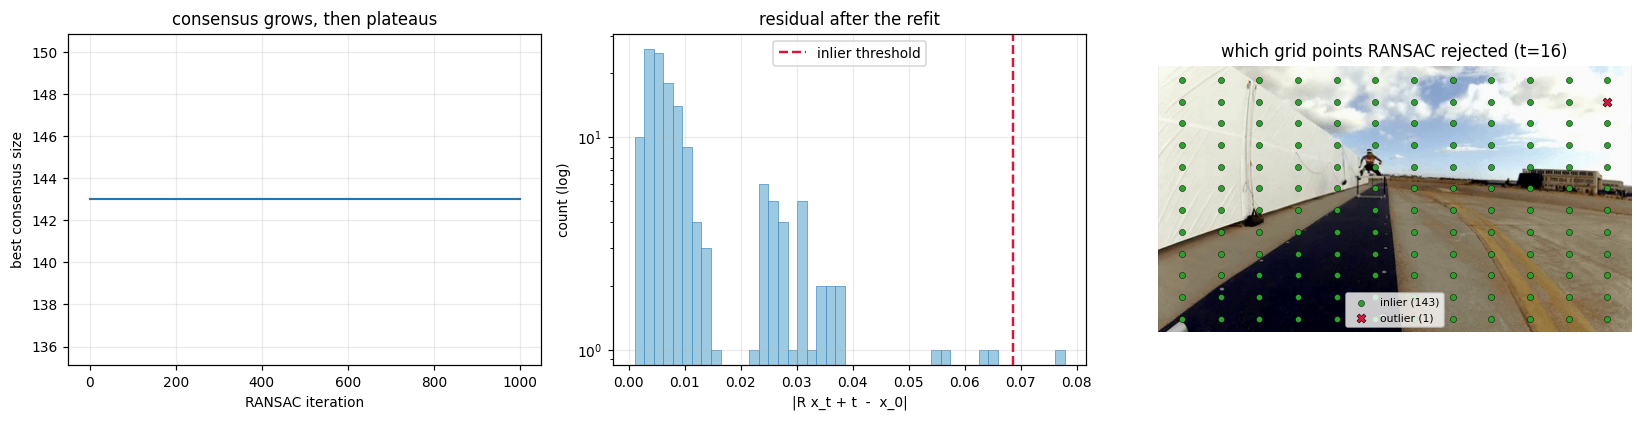

In [10]:
# One frame, in detail: how the consensus set is found and what it excludes.
cam_xyz = camera_npz["xyz_3d"].astype(np.float64)                       # (T, 144, 3)
cam_w   = np.where(sigmoid(camera_npz["visibility"]) > VISIBILITY_THRESHOLD,
                   sigmoid(camera_npz["confidence"]) ** 2, 0.0)         # (T, 144)
reference = cam_xyz[0]

DEMO_T = T // 2
demo = ransac_rigid(cam_xyz[DEMO_T], reference,
                    weights=np.minimum(cam_w[DEMO_T], cam_w[0]), seed=DEMO_T, trace=True)
print(f"frame {DEMO_T}: {demo['inliers'].sum()}/{len(demo['inliers'])} inliers, "
      f"threshold {demo['threshold']:.4f} (= 0.05 x cloud scale), rmse {demo['rmse']:.4f}, "
      f"sim3 scale {demo['scale']:.4f}")

fig = plt.figure(figsize=(15, 3.9))
ax = fig.add_subplot(1, 3, 1)
ax.plot(demo["history"], lw=1.4, color="#1f77b4")
ax.set_xlabel("RANSAC iteration"); ax.set_ylabel("best consensus size")
ax.set_title("consensus grows, then plateaus")

ax = fig.add_subplot(1, 3, 2)
res = demo["residual"][np.isfinite(demo["residual"])]
ax.hist(res, bins=45, color="#9ecae1", edgecolor="#3182bd", lw=0.4)
ax.axvline(demo["threshold"], color="crimson", lw=1.6, ls="--", label="inlier threshold")
ax.set_yscale("log"); ax.set_xlabel("|R x_t + t  -  x_0|"); ax.set_ylabel("count (log)")
ax.set_title("residual after the refit"); ax.legend()

ax = fig.add_subplot(1, 3, 3)
grid_uv = np.asarray(points["camera_grid_uv_norm"]) * [W - 1, H - 1]
ax.imshow(np.asarray(Image.open(FRAMES[DEMO_T])))
inl = demo["inliers"]
ax.scatter(grid_uv[inl, 0],  grid_uv[inl, 1],  s=16, c="#2ca02c", label=f"inlier ({inl.sum()})",
           edgecolors="black", linewidths=0.3)
ax.scatter(grid_uv[~inl, 0], grid_uv[~inl, 1], s=34, c="crimson", marker="X",
           label=f"outlier ({(~inl).sum()})", edgecolors="black", linewidths=0.4)
ax.set_title(f"which grid points RANSAC rejected (t={DEMO_T})"); ax.axis("off"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

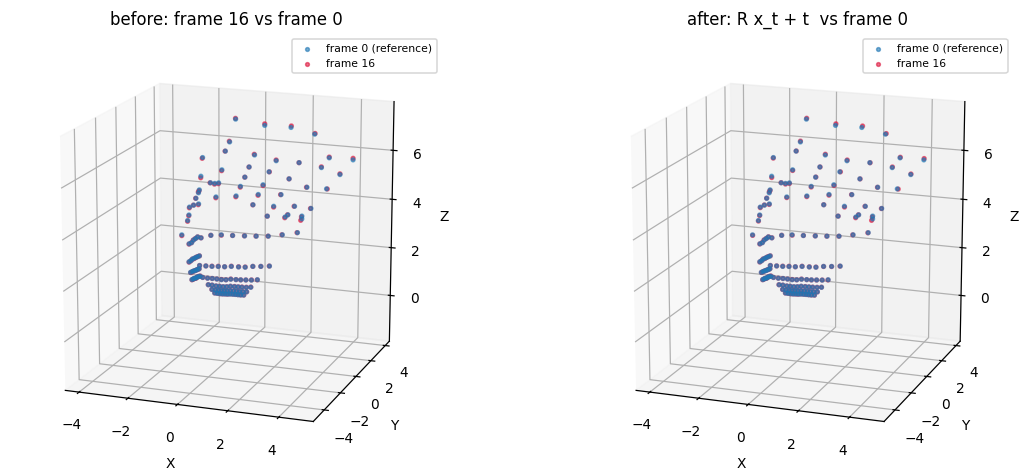

In [11]:
# The same fit seen in 3D: before alignment the two clouds are offset by the camera's motion.
R, t = demo["rotation"], demo["translation"]
aligned = cam_xyz[DEMO_T] @ R.T + t

fig = plt.figure(figsize=(11, 4.4))
for k, (src, title) in enumerate([(cam_xyz[DEMO_T], f"before: frame {DEMO_T} vs frame 0"),
                                  (aligned,          "after: R x_t + t  vs frame 0")]):
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.scatter(*reference.T, s=6, c="#1f77b4", alpha=0.6, label="frame 0 (reference)")
    ax.scatter(*src.T,       s=6, c="crimson", alpha=0.6, label=f"frame {DEMO_T}")
    ax.set_title(title); ax.view_init(elev=16, azim=-70); ax.legend(fontsize=7)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    equalise_3d(ax, np.vstack([reference, src]))
plt.tight_layout(); plt.show()

In [12]:
# Now every frame.  seed=t reproduces the pipeline's own RNG stream exactly.
rot   = np.tile(np.eye(3), (T, 1, 1))
trans = np.zeros((T, 3))
rmse  = np.full(T, np.nan); s3 = np.full(T, np.nan)
ninl  = np.zeros(T, int);   cond = np.full(T, np.nan)
inlier_masks = np.zeros((T, cam_xyz.shape[1]), bool)
failed = []

for tt in range(T):
    if tt == 0:
        ninl[0], rmse[0], s3[0] = int((cam_w[0] > 0).sum()), 0.0, 1.0
        continue
    fit = ransac_rigid(cam_xyz[tt], reference, weights=np.minimum(cam_w[tt], cam_w[0]), seed=tt)
    if fit is None:
        failed.append(tt); continue
    rot[tt], trans[tt] = fit["rotation"], fit["translation"]
    rmse[tt], s3[tt] = fit["rmse"], fit["scale"]
    ninl[tt], cond[tt] = int(fit["inliers"].sum()), fit["conditioning"]
    inlier_masks[tt] = fit["inliers"]

scene_scale = cloud_scale(reference)
rmse_rel = rmse / max(scene_scale, 1e-9)
cam_centres = np.einsum("tij,tj->ti", rot, np.zeros((T, 3))) + trans   # camera origin in frame-0 coords

def rotation_angle(Rm):
    return np.degrees(np.arccos(np.clip((np.trace(Rm) - 1) / 2, -1, 1)))
total_rot = sum(rotation_angle(rot[i] @ rot[i-1].T) for i in range(1, T))

print(f"scene scale {scene_scale:.4f}   median relative rmse {np.nanmedian(rmse_rel[1:]):.4f}"
      f"   median sim3 scale {np.nanmedian(s3[1:]):.4f}")
print(f"min inliers {ninl[1:].min()}/{cam_xyz.shape[1]}   total camera rotation {total_rot:.2f} deg"
      f"   failed frames {failed or 'none'}")

scene scale 1.3738   median relative rmse 0.0129   median sim3 scale 0.9992
min inliers 142/144   total camera rotation 1.38 deg   failed frames none


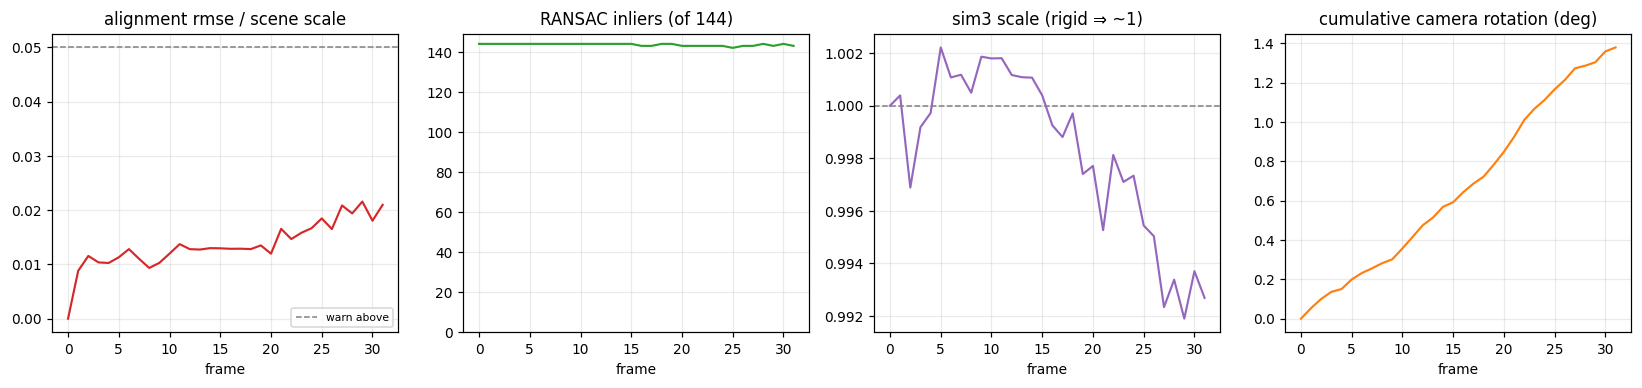

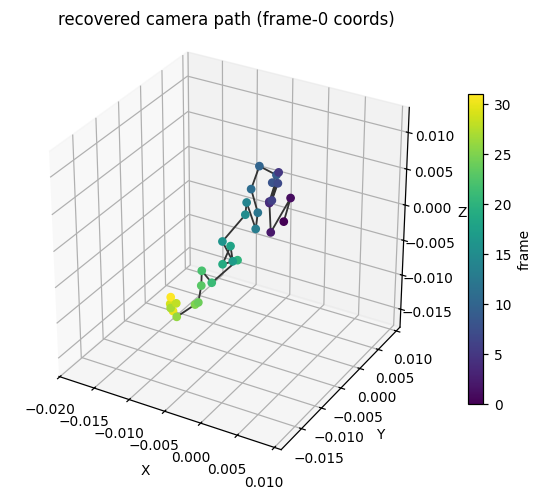

In [13]:
fig = plt.figure(figsize=(15, 3.6))
ax = fig.add_subplot(1, 4, 1); ax.plot(rmse_rel, lw=1.4, color="#d62728")
ax.axhline(0.05, ls="--", lw=1, color="grey", label="warn above")
ax.set_xlabel("frame"); ax.set_title("alignment rmse / scene scale"); ax.legend(fontsize=7)

ax = fig.add_subplot(1, 4, 2); ax.plot(ninl, lw=1.4, color="#2ca02c")
ax.set_ylim(0, cam_xyz.shape[1] + 5); ax.set_xlabel("frame"); ax.set_title("RANSAC inliers (of 144)")

ax = fig.add_subplot(1, 4, 3); ax.plot(s3, lw=1.4, color="#9467bd")
ax.axhline(1.0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_title("sim3 scale (rigid ⇒ ~1)")

ax = fig.add_subplot(1, 4, 4)
ang = [0.0] + [rotation_angle(rot[i] @ rot[i-1].T) for i in range(1, T)]
ax.plot(np.cumsum(ang), lw=1.4, color="#ff7f0e")
ax.set_xlabel("frame"); ax.set_title("cumulative camera rotation (deg)")
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(5.4, 4.4))
ax = fig.add_subplot(projection="3d")
ax.plot(*cam_centres.T, color="#333333", lw=1.2)
sc = ax.scatter(*cam_centres.T, c=np.arange(T), cmap="viridis", s=22, depthshade=False)
ax.set_title("recovered camera path (frame-0 coords)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
equalise_3d(ax, cam_centres); fig.colorbar(sc, ax=ax, label="frame", fraction=0.03)
plt.tight_layout(); plt.show()

### The camera path, one axis at a time

The 3D path above is easy to look at and hard to read numbers off. Here are the same camera
centres split into the three axes the subject plots use — **+x right, +y down, +z forward**, in
D4RT units — plus the same Savitzky–Golay filter that step 6 applies to the subject trajectory.

The grey curve is the raw per-frame RANSAC translation. Every frame was fitted against frame 0
*independently*: there is no temporal term anywhere in `robust_rigid`, no prior linking frame $t$
to frame $t-1$. So wobble in the grey curve is estimation noise, not camera shake — a real camera
cannot change direction between adjacent frames the way a bad fit can. That is exactly what makes
the raw-vs-smoothed gap worth reading: it is a noise estimate for the camera fit.

Compare the axes by their *printed ranges*, not by how ragged they look. Each panel is
autoscaled, so an axis the camera barely moved along is drawn at enormous magnification and its
noise fills the panel — it looks like the worst-estimated axis when it is really just the
smallest one. The range line below the figure is what tells you which is which.

Two things this is *not*:

* **It is not fed back.** `cam_smooth` is diagnostic only. Nothing downstream consumes it, and the
  step 8 verification still compares the raw `rot`/`trans` against what the pipeline wrote.
* **It is translation only.** Rotations cannot go through a Savitzky–Golay filter as matrices — a
  per-element polynomial fit of nine entries leaves $R^\top R = I$ broken. Smoothing those
  properly needs SLERP over quaternions, which the pipeline does not do either.

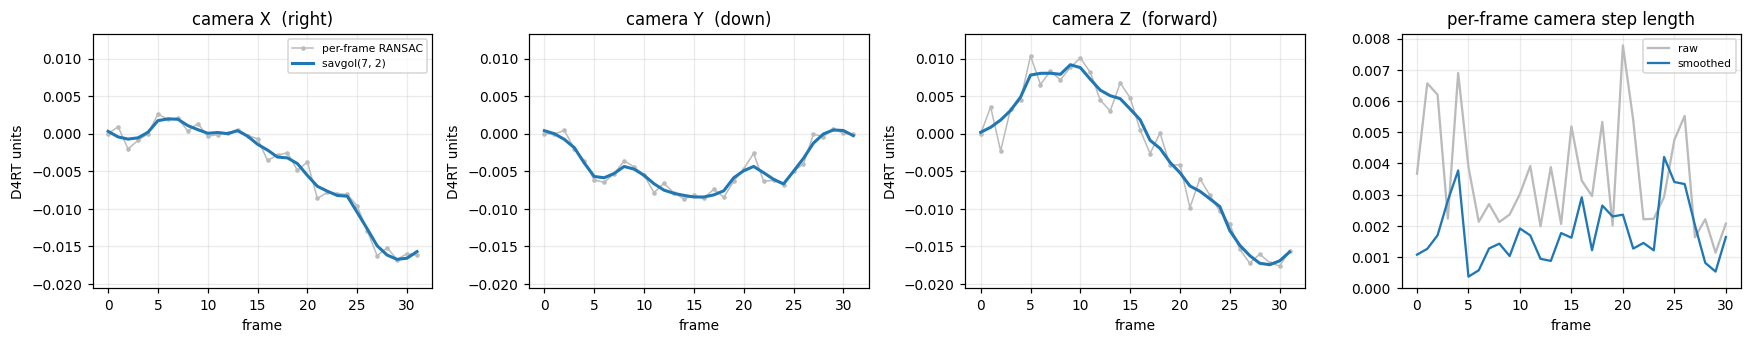

camera X (right  ) range  0.0194   =   0.01 x scene scale
camera Y (down   ) range  0.0094   =   0.01 x scene scale
camera Z (forward) range  0.0280   =   0.02 x scene scale

path length   raw 0.1104  ->  smoothed 0.0554   (49.8% shorter)
rms jerk      raw 0.0062  ->  smoothed 0.0015   (76.0% lower)

A large drop means the per-frame fits disagree with each other frame to frame, i.e. the
camera estimate is noisy.  A small drop means the fits were already temporally coherent.


In [14]:
from scipy.signal import savgol_filter

def smooth_trajectory(track, window=7, polyorder=2):
    """Savitzky-Golay per coordinate.  Gaps are linearly interpolated so the filter sees a
    continuous signal, then restored to NaN so absent frames stay absent.

    Defined here because the camera path needs it first; step 6 applies this same function
    to the subject trajectory."""
    track = np.asarray(track, float)
    finite = np.isfinite(track).all(axis=1)
    if finite.sum() < max(window, polyorder + 2):
        return track.copy()
    filled = track.copy()
    if not finite.all():
        i = np.arange(len(track))
        for a in range(3):
            filled[:, a] = np.interp(i, i[finite], track[finite, a])
    window = min(window, len(filled) if len(filled) % 2 == 1 else len(filled) - 1)
    if window <= polyorder:
        return track.copy()
    out = savgol_filter(filled, window_length=window, polyorder=polyorder, axis=0, mode="interp")
    out[~finite] = np.nan
    return out

cam_track = cam_centres.copy()
cam_track[failed] = np.nan          # a failed fit leaves trans = 0, which is not a measurement
cam_smooth = smooth_trajectory(cam_track)

AXIS = [("X", "right"), ("Y", "down"), ("Z", "forward")]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    ax.plot(cam_track[:, k],  lw=1.0, color="#bbbbbb", marker=".", ms=4, label="per-frame RANSAC")
    ax.plot(cam_smooth[:, k], lw=2.0, color="#1f77b4", label="savgol(7, 2)")
    ax.set_xlabel("frame"); ax.set_ylabel("D4RT units")
    ax.set_title(f"camera {AXIS[k][0]}  ({AXIS[k][1]})")
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])                       # X, Y, Z share one scale; the step-length panel does not
axes[3].plot(np.linalg.norm(np.diff(cam_track,  axis=0), axis=1), color="#bbbbbb", label="raw")
axes[3].plot(np.linalg.norm(np.diff(cam_smooth, axis=0), axis=1), color="#1f77b4", label="smoothed")
axes[3].set_xlabel("frame"); axes[3].set_title("per-frame camera step length"); axes[3].legend(fontsize=7)
plt.tight_layout(); plt.show()

def jerk(track):                     # rms second difference -- frame-to-frame incoherence
    d2 = np.diff(track, n=2, axis=0)
    d2 = d2[np.isfinite(d2).all(axis=1)]
    return float(np.sqrt((d2 ** 2).sum(axis=1).mean())) if len(d2) else np.nan

def plen(track):
    d = np.diff(track, axis=0)
    d = d[np.isfinite(d).all(axis=1)]
    return float(np.linalg.norm(d, axis=1).sum())

for k, (nm, direction) in enumerate(AXIS):
    col = cam_track[:, k][np.isfinite(cam_track[:, k])]
    print(f"camera {nm} ({direction:7s}) range {col.max() - col.min():7.4f}   "
          f"= {(col.max() - col.min()) / scene_scale:6.2f} x scene scale")
print(f"\npath length   raw {plen(cam_track):.4f}  ->  smoothed {plen(cam_smooth):.4f}"
      f"   ({100 * (1 - plen(cam_smooth) / max(plen(cam_track), 1e-9)):.1f}% shorter)")
print(f"rms jerk      raw {jerk(cam_track):.4f}  ->  smoothed {jerk(cam_smooth):.4f}"
      f"   ({100 * (1 - jerk(cam_smooth) / max(jerk(cam_track), 1e-9)):.1f}% lower)")
print("\nA large drop means the per-frame fits disagree with each other frame to frame, i.e. the")
print("camera estimate is noisy.  A small drop means the fits were already temporally coherent.")

### Which grid points is the camera fit actually listening to?

Worth checking, because the grid is uniform over the *stored* frame — and these clips are
letterboxed. A grid point on a black bar has no image content behind it, so whatever depth D4RT
invents for it is near-constant across frames, which makes it a perfect rigid inlier. If most of
the consensus set is padding, the recovered "camera motion" is largely the statement that the
padding did not move, and the low residual is not evidence that the fit is right.

Nothing in `traj3d_analyze.py` looks at this, and it does not trip the rmse warning — padding fits
*better* than real content, so it pushes the residual down.

11/144 grid points sit on black padding
mean inlier rate   padding 1.00   image content 1.00
depth std over frames   padding 0.123   image content 2.122
share of the consensus set that is padding: 8%


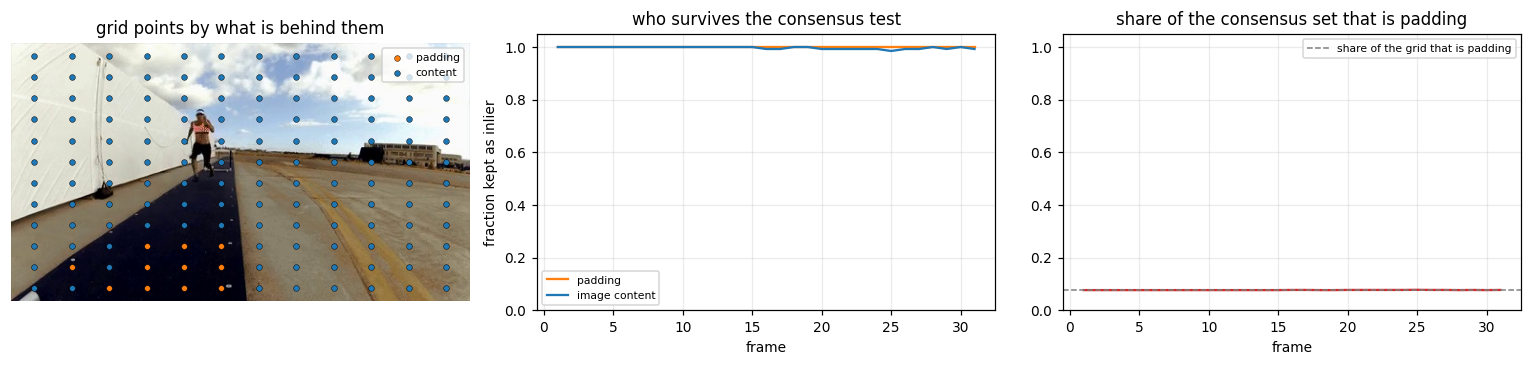

In [15]:
lum = np.stack([np.asarray(Image.open(f).convert("L"), dtype=float) for f in FRAMES])  # (T, H, W)
gi = np.round(grid_px).astype(int)
gi[:, 0] = np.clip(gi[:, 0], 0, W - 1); gi[:, 1] = np.clip(gi[:, 1], 0, H - 1)
is_pad = (lum[:, gi[:, 1], gi[:, 0]] < 12).all(axis=0)          # dark in every frame -> letterbox

if is_pad.sum() == 0:
    print("no letterbox padding on this clip -- every grid point sits on real image content")
else:
    rate_pad = inlier_masks[1:][:, is_pad].mean(axis=1)
    rate_con = inlier_masks[1:][:, ~is_pad].mean(axis=1)
    print(f"{is_pad.sum()}/{len(is_pad)} grid points sit on black padding")
    print(f"mean inlier rate   padding {rate_pad.mean():.2f}   image content {rate_con.mean():.2f}")
    print(f"depth std over frames   padding {np.nanstd(cam_xyz[:, is_pad, 2]):.3f}"
          f"   image content {np.nanstd(cam_xyz[:, ~is_pad, 2]):.3f}")
    frac = inlier_masks[1:][:, is_pad].sum(axis=1) / np.maximum(inlier_masks[1:].sum(axis=1), 1)
    print(f"share of the consensus set that is padding: {frac.mean():.0%}")

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
    axes[0].imshow(np.asarray(Image.open(FRAMES[seed_t])))
    axes[0].scatter(grid_px[is_pad, 0], grid_px[is_pad, 1], s=14, c="#ff7f0e", label="padding",
                    edgecolors="black", linewidths=0.3)
    axes[0].scatter(grid_px[~is_pad, 0], grid_px[~is_pad, 1], s=14, c="#1f77b4", label="content",
                    edgecolors="black", linewidths=0.3)
    axes[0].axis("off"); axes[0].set_title("grid points by what is behind them"); axes[0].legend(fontsize=7)

    axes[1].plot(np.arange(1, T), rate_pad, lw=1.5, color="#ff7f0e", label="padding")
    axes[1].plot(np.arange(1, T), rate_con, lw=1.5, color="#1f77b4", label="image content")
    axes[1].set_ylim(0, 1.05); axes[1].set_xlabel("frame"); axes[1].set_ylabel("fraction kept as inlier")
    axes[1].set_title("who survives the consensus test"); axes[1].legend(fontsize=7)

    axes[2].plot(np.arange(1, T), frac, lw=1.5, color="#d62728")
    axes[2].axhline(is_pad.mean(), ls="--", lw=1, color="grey", label="share of the grid that is padding")
    axes[2].set_ylim(0, 1.05); axes[2].set_xlabel("frame")
    axes[2].set_title("share of the consensus set that is padding"); axes[2].legend(fontsize=7)
    plt.tight_layout(); plt.show()

## Step 4 — rejecting whole tracks

Rejection happens at **track** level, not per frame. The reasoning matters:

* a bad D4RT point latched onto the wrong surface *when it was seeded*, so it is wrong for its
  entire track;
* the subject is non-rigid, so a per-frame consensus would swap physical identity between frames —
  a swinging forearm is an inlier in some frames and an outlier in others — producing a jittery
  trajectory with a wandering bias.

Three tests, applied in order, each on the surviving set. `scale` below is the subject cloud's own
`cloud_scale`.

| Test | Question | Reject when |
|---|---|---|
| **B1 membership** | is the point even on the subject? | median distance to the per-frame centre > `3 × scale` |
| **B2 bulk motion** | does it translate *with* the subject? | displacement disagrees with consensus at lags 4/8/16/31 by > `2 × scale`, or > median + 3·MAD |
| **B3 smoothness** | does it flicker? | second difference > median + 3·MAD |

B2 is evaluated at long lags on purpose: at lag 1 limb swing dominates and the test over-rejects.

In [16]:
def mad(v):
    """Median absolute deviation, scaled so it estimates sigma for a normal."""
    v = np.asarray(v, float); v = v[np.isfinite(v)]
    return float("nan") if v.size == 0 else float(1.4826 * np.median(np.abs(v - np.median(v))))

MEMBERSHIP_RATIO, MOTION_RATIO, LAGS = 3.0, 2.0, (4, 8, 16, 31)

centre = np.nanmedian(masked, axis=0)                                   # (T, 3) per-frame centroid
scale  = cloud_scale(masked[np.isfinite(masked).all(axis=-1)])
keep   = np.ones(P, bool)
reasons = {"membership": [], "bulk_motion": [], "smoothness": []}
print(f"subject cloud scale = {scale:.4f}  (all thresholds below are multiples of this)")

subject cloud scale = 0.5356  (all thresholds below are multiples of this)


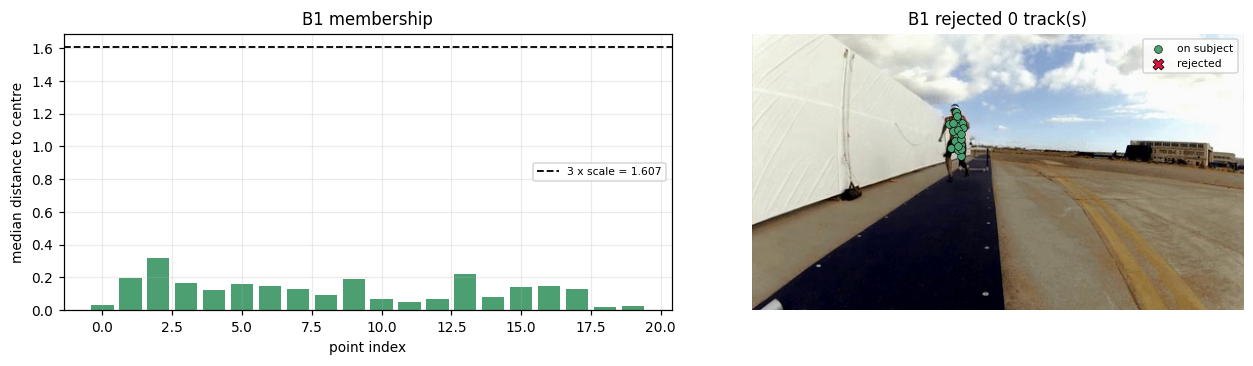

In [17]:
# --- B1: membership ------------------------------------------------------
radius = np.nanmedian(np.linalg.norm(masked - centre[None], axis=-1), axis=1)   # (P,)
reject = np.nan_to_num(radius, nan=np.inf) > MEMBERSHIP_RATIO * scale
reasons["membership"] = np.flatnonzero(reject).tolist()
keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].bar(np.arange(P), radius, color=np.where(reject, "crimson", "#4c9f70"))
axes[0].axhline(MEMBERSHIP_RATIO * scale, ls="--", color="black", lw=1.2,
                label=f"3 x scale = {MEMBERSHIP_RATIO*scale:.3f}")
axes[0].set_xlabel("point index"); axes[0].set_ylabel("median distance to centre")
axes[0].set_title("B1 membership"); axes[0].legend(fontsize=7)

axes[1].imshow(np.asarray(Image.open(FRAMES[seed_t])))
pts_seed = uv[:, seed_t] * [W - 1, H - 1]
axes[1].scatter(pts_seed[~reject, 0], pts_seed[~reject, 1], s=26, c="#4c9f70",
                edgecolors="black", linewidths=0.4, label="on subject")
axes[1].scatter(pts_seed[reject, 0], pts_seed[reject, 1], s=52, c="crimson", marker="X",
                edgecolors="black", linewidths=0.5, label="rejected")
axes[1].axis("off"); axes[1].set_title(f"B1 rejected {reject.sum()} track(s)"); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

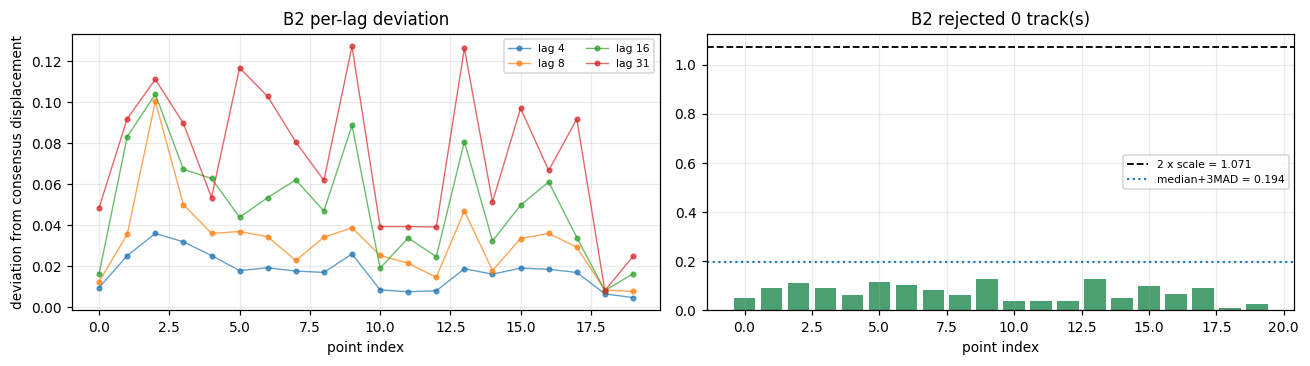

In [18]:
# --- B2: does the track translate with the subject? ----------------------
motion_residual = np.zeros(P)
per_lag = {}
for lag in LAGS:
    if lag >= T: continue
    delta = masked[:, lag:] - masked[:, :-lag]                  # (P, T-lag, 3) displacement over `lag`
    consensus = np.nanmedian(delta, axis=0)                     # what the subject as a whole did
    dev = np.nanmedian(np.linalg.norm(delta - consensus[None], axis=-1), axis=1)
    per_lag[lag] = np.nan_to_num(dev, nan=np.inf)
    motion_residual = np.maximum(motion_residual, per_lag[lag])

reject = motion_residual > MOTION_RATIO * scale
mad_cutoff = np.nan
if keep.sum() > 2:
    mad_cutoff = np.nanmedian(motion_residual[keep]) + 3.0 * mad(motion_residual[keep])
    if np.isfinite(mad_cutoff):
        reject |= motion_residual > mad_cutoff
reasons["bulk_motion"] = np.flatnonzero(reject & keep).tolist()
keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for lag, dev in per_lag.items():
    axes[0].plot(np.clip(dev, 0, np.nanmax(motion_residual[np.isfinite(motion_residual)]) * 1.2),
                 marker="o", ms=3, lw=0.9, alpha=0.7, label=f"lag {lag}")
axes[0].set_xlabel("point index"); axes[0].set_ylabel("deviation from consensus displacement")
axes[0].set_title("B2 per-lag deviation"); axes[0].legend(fontsize=7, ncol=2)

axes[1].bar(np.arange(P), np.clip(motion_residual, 0, np.inf),
            color=np.where(reject, "crimson", "#4c9f70"))
axes[1].axhline(MOTION_RATIO * scale, ls="--", color="black", lw=1.2, label=f"2 x scale = {MOTION_RATIO*scale:.3f}")
if np.isfinite(mad_cutoff):
    axes[1].axhline(mad_cutoff, ls=":", color="#1f77b4", lw=1.4, label=f"median+3MAD = {mad_cutoff:.3f}")
axes[1].set_xlabel("point index"); axes[1].set_title(f"B2 rejected {len(reasons['bulk_motion'])} track(s)")
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

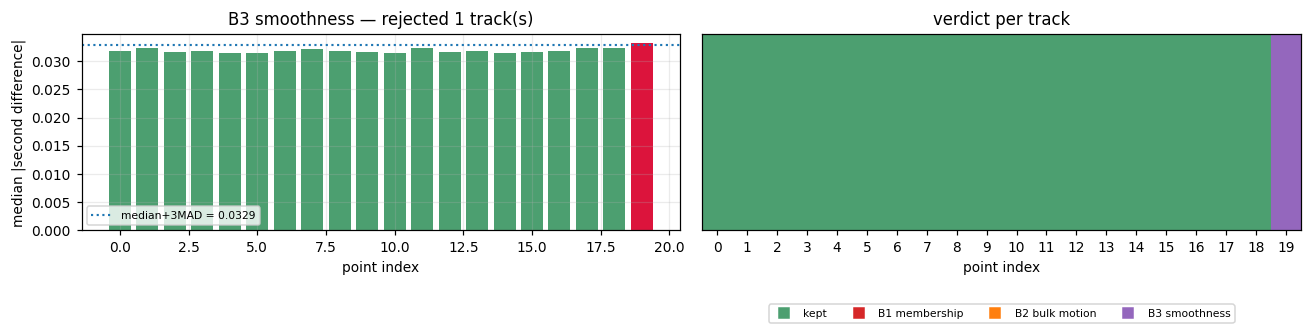

kept 19/20 tracks   rejected: {'membership': [], 'bulk_motion': [], 'smoothness': [19]}


In [19]:
# --- B3: flicker ---------------------------------------------------------
second = masked[:, 2:] - 2.0 * masked[:, 1:-1] + masked[:, :-2]      # discrete acceleration
jitter = np.nanmedian(np.linalg.norm(second, axis=-1), axis=1)
jitter_cutoff = np.nan
if keep.sum() > 2:
    jitter_cutoff = np.nanmedian(jitter[keep]) + 3.0 * mad(jitter[keep])
    if np.isfinite(jitter_cutoff):
        reject = np.nan_to_num(jitter, nan=np.inf) > jitter_cutoff
        reasons["smoothness"] = np.flatnonzero(reject & keep).tolist()
        keep &= ~reject

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].bar(np.arange(P), jitter, color=["crimson" if p in reasons["smoothness"] else "#4c9f70" for p in range(P)])
if np.isfinite(jitter_cutoff):
    axes[0].axhline(jitter_cutoff, ls=":", color="#1f77b4", lw=1.4, label=f"median+3MAD = {jitter_cutoff:.4f}")
    axes[0].legend(fontsize=7)
axes[0].set_xlabel("point index"); axes[0].set_ylabel("median |second difference|")
axes[0].set_title(f"B3 smoothness — rejected {len(reasons['smoothness'])} track(s)")

status = np.zeros(P)
for r, code_ in (("membership", 1), ("bulk_motion", 2), ("smoothness", 3)):
    status[reasons[r]] = code_
axes[1].imshow(status[None], aspect="auto", cmap=mcolors.ListedColormap(
    ["#4c9f70", "#d62728", "#ff7f0e", "#9467bd"]), vmin=0, vmax=3)
axes[1].set_yticks([]); axes[1].set_xticks(range(P)); axes[1].set_xlabel("point index")
axes[1].grid(False); axes[1].set_title("verdict per track")
axes[1].legend(handles=[Line2D([], [], marker="s", ls="", color=c, label=l) for c, l in
                        [("#4c9f70", "kept"), ("#d62728", "B1 membership"),
                         ("#ff7f0e", "B2 bulk motion"), ("#9467bd", "B3 smoothness")]],
               fontsize=7, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.35))
plt.tight_layout(); plt.show()

print(f"kept {keep.sum()}/{P} tracks   rejected: {reasons}")

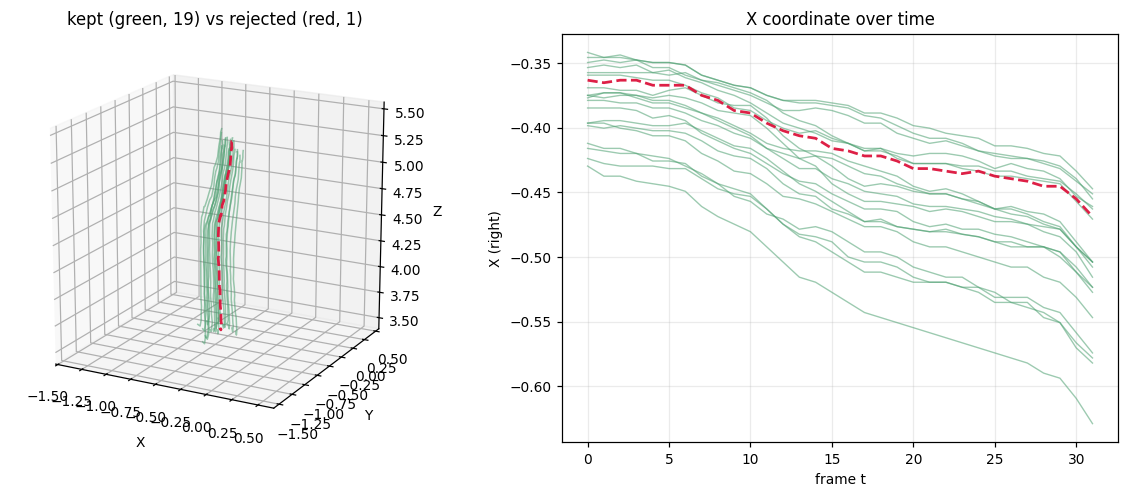

In [20]:
# What survived, in 3D.
fig = plt.figure(figsize=(11, 4.6))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for p in range(P):
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() < 2: continue
    ax.plot(*masked[p, ok].T, color=("#4c9f70" if keep[p] else "crimson"),
            lw=(1.0 if keep[p] else 1.8), alpha=(0.55 if keep[p] else 0.95),
            ls=("-" if keep[p] else "--"))
ax.set_title(f"kept (green, {keep.sum()}) vs rejected (red, {(~keep).sum()})")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z"); ax.view_init(elev=18, azim=-62)
equalise_3d(ax, masked.reshape(-1, 3))

ax = fig.add_subplot(1, 2, 2)
for p in range(P):
    ax.plot(masked[p, :, 0], color=("#4c9f70" if keep[p] else "crimson"),
            lw=(0.9 if keep[p] else 1.8), alpha=(0.55 if keep[p] else 0.95),
            ls=("-" if keep[p] else "--"))
ax.set_xlabel("frame t"); ax.set_ylabel("X (right)"); ax.set_title("X coordinate over time")
plt.tight_layout(); plt.show()

## Step 5 — the median: one point per frame

For each frame, collapse the surviving tracks into a single position. The pipeline uses the
**weighted geometric median** (the L1 multivariate median), computed with Weiszfeld's algorithm:

$$c \leftarrow \frac{\sum_i w_i\,x_i / \lVert x_i - c\rVert}{\sum_i w_i / \lVert x_i - c\rVert}$$

with $w_i = \sigma(\text{confidence})^2$. It minimises the sum of *distances*, not squared
distances.

Why not the alternatives:

* the **mean** has breakdown point 0 — a single bad track moves it;
* the **per-coordinate median** is not rotation-equivariant, so the answer would depend on the
  arbitrary orientation of the camera frame.

With fewer than 4 points the implementation falls back to the per-coordinate median (Weiszfeld
is not worth it there).

In [21]:
def geometric_median(pts, w=None, iters=64, eps=1e-9, trace=False):
    """Weighted L1 multivariate median via Weiszfeld iteration."""
    pts = np.asarray(pts, float)
    if len(pts) == 0: return (np.full(3, np.nan), []) if trace else np.full(3, np.nan)
    w = np.ones(len(pts)) if w is None else np.asarray(w, float)
    if len(pts) < 4:
        m = np.median(pts, axis=0)
        return (m, [m]) if trace else m

    c = np.average(pts, axis=0, weights=w)        # start from the weighted mean
    history = [c.copy()]
    for _ in range(iters):
        d = np.maximum(np.linalg.norm(pts - c, axis=1), eps)
        ww = w / d                                # closer points pull harder
        nxt = (pts * ww[:, None]).sum(0) / ww.sum()
        history.append(nxt.copy())
        if np.linalg.norm(nxt - c) < eps * (1.0 + np.linalg.norm(c)):
            c = nxt; break
        c = nxt
    return (c, np.array(history)) if trace else c

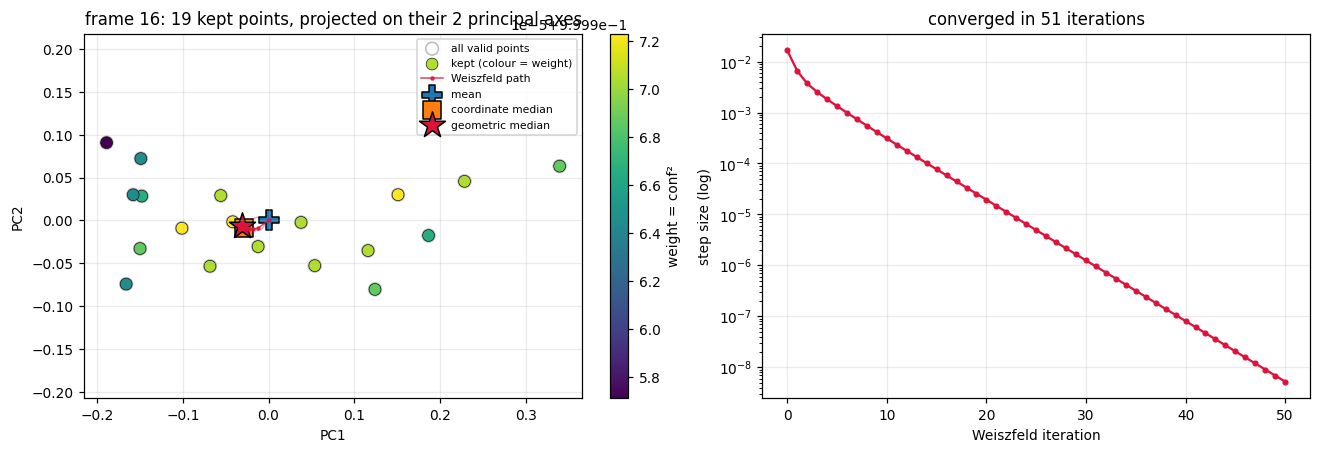

mean               [-0.4458 -0.587   4.5312]
coordinate median  [-0.4414 -0.6016  4.5625]
geometric median   [-0.4486 -0.6073  4.5569]    (moved 0.0328 off the mean)


In [22]:
# One frame in close-up: mean vs coordinate median vs geometric median, and the Weiszfeld path.
DEMO_F = T // 2
frame_valid = valid[:, DEMO_F] & np.isfinite(xyz[:, DEMO_F]).all(axis=-1)
sel = frame_valid & keep
pts, wts = xyz[sel, DEMO_F], weights[sel, DEMO_F]
gm, hist = geometric_median(pts, wts, trace=True)

# project on the cloud's two principal axes so the picture is not an arbitrary slice
c0 = pts.mean(0)
basis = np.linalg.svd(pts - c0, full_matrices=False)[2][:2]
proj = lambda X: (np.atleast_2d(X) - c0) @ basis.T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
allp = xyz[frame_valid, DEMO_F]
ax.scatter(*proj(allp).T, s=70, facecolors="none", edgecolors="#bbbbbb", label="all valid points")
sc = ax.scatter(*proj(pts).T, s=60, c=wts, cmap="viridis", edgecolors="black", linewidths=0.4,
                label="kept (colour = weight)")
ax.plot(*proj(hist).T, color="crimson", lw=1.0, marker=".", ms=4, alpha=0.8, label="Weiszfeld path")
ax.scatter(*proj(pts.mean(0)).T, marker="P", s=170, c="#1f77b4", edgecolors="black", label="mean")
ax.scatter(*proj(np.median(allp, axis=0)).T, marker="s", s=130, c="#ff7f0e", edgecolors="black",
           label="coordinate median")
ax.scatter(*proj(gm).T, marker="*", s=320, c="crimson", edgecolors="black", label="geometric median")
ax.set_title(f"frame {DEMO_F}: {sel.sum()} kept points, projected on their 2 principal axes")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(fontsize=7, framealpha=0.85)
ax.set_aspect("equal", adjustable="datalim")     # equal scale, but fill the box
fig.colorbar(sc, ax=ax, fraction=0.04, label="weight = conf²")

ax = axes[1]
ax.semilogy(np.linalg.norm(np.diff(hist, axis=0), axis=1), marker="o", ms=3, color="crimson")
ax.set_xlabel("Weiszfeld iteration"); ax.set_ylabel("step size (log)")
ax.set_title(f"converged in {len(hist)-1} iterations")
plt.tight_layout(); plt.show()

print("mean              ", pts.mean(0))
print("coordinate median ", np.median(allp, axis=0))
print("geometric median  ", gm, f"   (moved {np.linalg.norm(gm - pts.mean(0)):.4f} off the mean)")

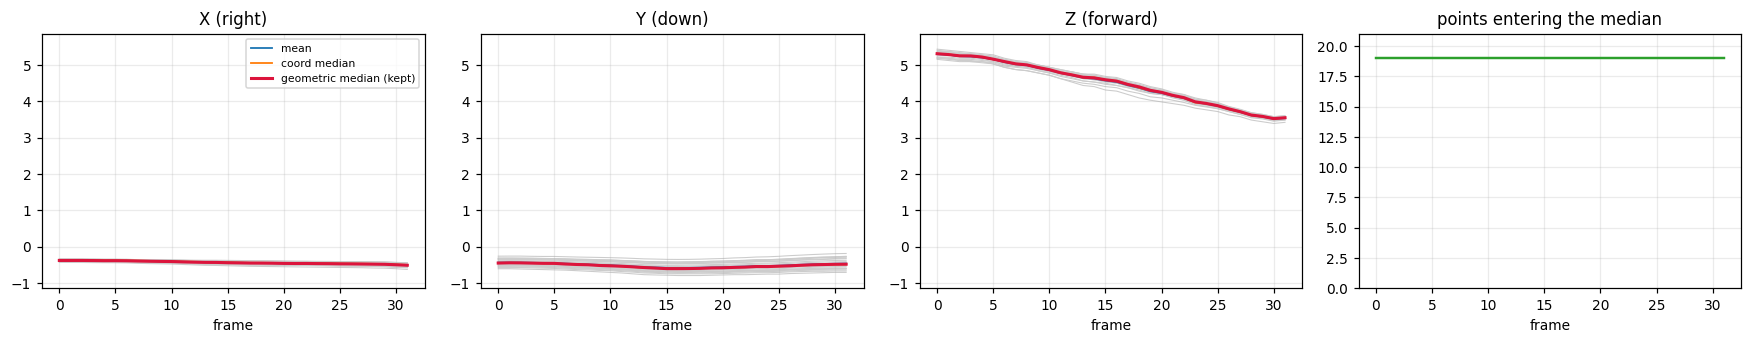

In [23]:
# Now every frame -- this is aggregate_trajectory().
agg = {"mean": np.full((T, 3), np.nan), "median": np.full((T, 3), np.nan),
       "ransac_median": np.full((T, 3), np.nan), "n_inliers": np.zeros(T, int)}
for tt in range(T):
    fv = valid[:, tt] & np.isfinite(xyz[:, tt]).all(axis=-1)
    if fv.any():
        agg["mean"][tt]   = xyz[fv, tt].mean(axis=0)
        agg["median"][tt] = np.median(xyz[fv, tt], axis=0)
    s = fv & keep
    agg["n_inliers"][tt] = int(s.sum())
    if s.any():
        agg["ransac_median"][tt] = geometric_median(xyz[s, tt], weights[s, tt])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    for p in range(P):
        if keep[p]: ax.plot(masked[p, :, k], color="#cccccc", lw=0.7, zorder=1)
    ax.plot(agg["mean"][:, k], lw=1.2, color="#1f77b4", label="mean")
    ax.plot(agg["median"][:, k], lw=1.2, color="#ff7f0e", label="coord median")
    ax.plot(agg["ransac_median"][:, k], lw=2.0, color="crimson", label="geometric median (kept)")
    ax.set_xlabel("frame"); ax.set_title("XYZ"[k] + " " + ["(right)", "(down)", "(forward)"][k])
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])
axes[3].plot(agg["n_inliers"], lw=1.6, color="#2ca02c")
axes[3].set_ylim(0, P + 1); axes[3].set_xlabel("frame"); axes[3].set_title("points entering the median")
plt.tight_layout(); plt.show()

## Step 6 — Savitzky–Golay smoothing

A length-7 window, order-2 polynomial fit, applied per coordinate. Gaps are linearly interpolated
first so the filter sees a continuous signal, then restored to NaN, so absent frames stay absent.
`smooth_trajectory` is the function defined back in step 3, where the camera path needed it first —
the subject and the camera get the identical filter.

Order matters: smoothing **after** outlier rejection, never before. Smoothing first would blend the
outliers into their neighbours and hide exactly what step 4 is looking for.

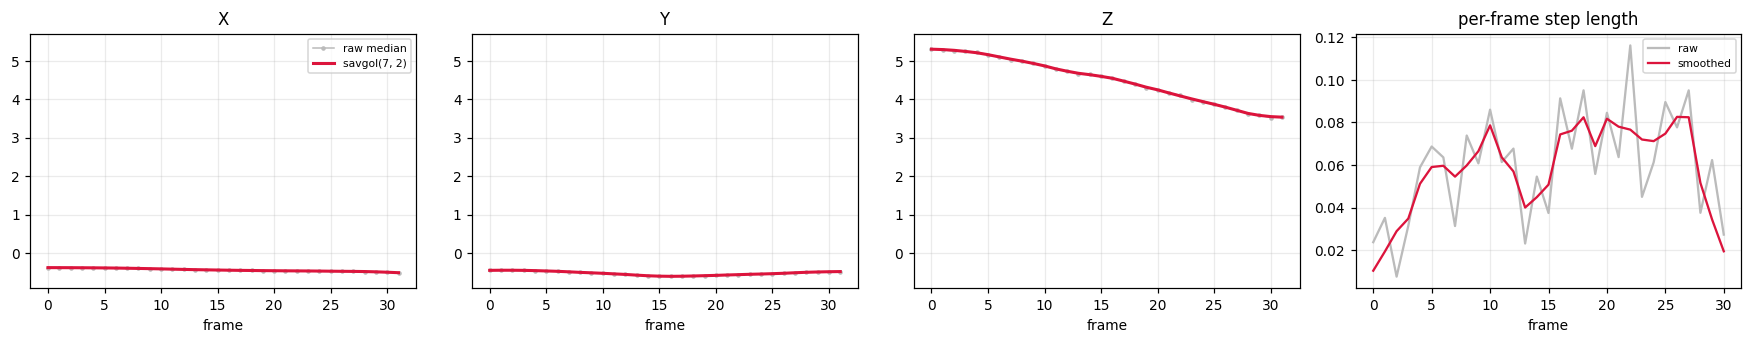

In [24]:
smoothed = smooth_trajectory(agg["ransac_median"])

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, k in zip(axes, range(3)):
    ax.plot(agg["ransac_median"][:, k], lw=1.0, color="#bbbbbb", marker=".", ms=4, label="raw median")
    ax.plot(smoothed[:, k], lw=2.0, color="crimson", label="savgol(7, 2)")
    ax.set_xlabel("frame"); ax.set_title("XYZ"[k])
    if k == 0: ax.legend(fontsize=7)
lock_axes(axes[:3])
step = np.linalg.norm(np.diff(agg["ransac_median"], axis=0), axis=1)
axes[3].plot(step, color="#bbbbbb", label="raw")
axes[3].plot(np.linalg.norm(np.diff(smoothed, axis=0), axis=1), color="crimson", label="smoothed")
axes[3].set_xlabel("frame"); axes[3].set_title("per-frame step length"); axes[3].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Step 7 — post-processing: smoothing and axis filtering

Everything up to here reproduces the pipeline exactly. This step deliberately does *not* — it is
extra cleanup applied on top, and nothing downstream of the notebook consumes it.

Two operations, both applied to the subject trajectory and the camera path with the same code:

1. **Running mean over 5 frames.** A plain box average. This is now the smoother of record:
   the savgol curve is commented out of the plots below, and the running mean is what feeds the
   axis filter. Savgol is still *computed* in step 6, because the step 8 verification compares
   against the pipeline and the pipeline uses it — it is just no longer drawn. The two are
   compared head to head, on cost and on quality, at the end of this step.
2. **Axis filtering.** If one axis carries far less motion than the busiest one, treat it as noise
   and flatten it to its median.

On "deterministic": the pipeline already is. `robust_rigid` is seeded with `seed=t`, so a rerun is
bit-identical — the step 8 verification below shows `0.000e+00` against the stored output, and that
is a rerun agreeing with itself. Nothing here adds determinism; what it adds is *stability*, which
is the different property of not wobbling frame to frame.

### On measuring an axis in centimetres

You can't, from these arrays. D4RT's units are arbitrary — the training loss normalises each clip
by its own mean depth — so the same physical 15 cm is a different number in every clip, and an
absolute cutoff would be strict on one and inert on the next. Two relative tests instead:

* **share of the busiest axis** — keep an axis when its span is at least `AXIS_KEEP_RATIO` of the
  largest axis span. This is the test as you described it: 15 cm against 2 m is a ratio of 0.075.
* **against the clip's own noise floor** — the scatter of the raw signal about the smoothed one is
  a direct estimate of the per-axis noise. An axis whose whole range is comparable to its own noise
  is not measuring motion, regardless of what the other axes do.

Both are printed, and `AXIS_RULE` picks which one decides. They do not always agree, and the
disagreement is the interesting part: an axis can be far above its own noise floor — real,
measured motion — and still be small next to the busiest axis. The ratio rule discards it anyway.
That is a modelling choice ("I only care about the dominant direction"), not a noise removal, and
it is worth being clear which one you are making. Watch the `span/noise` column when an axis gets
flattened: a large value there means you just threw away signal, not noise.

In [25]:
def running_mean(track, window=5):
    """Centred box average.  Gaps are interpolated for the filter then restored, and the window
    shrinks at the ends rather than padding -- no invented data outside the clip."""
    track = np.asarray(track, float)
    finite = np.isfinite(track).all(axis=1)
    if finite.sum() < 2:
        return track.copy()
    filled = track.copy()
    if not finite.all():
        i = np.arange(len(track))
        for a in range(3):
            filled[:, a] = np.interp(i, i[finite], track[finite, a])
    half, n = window // 2, len(filled)
    out = np.empty_like(filled)
    for t in range(n):
        out[t] = filled[max(0, t - half):min(n, t + half + 1)].mean(axis=0)
    out[~finite] = np.nan
    return out


def axis_spans(track):
    """Robust per-axis extent: the 5th-to-95th percentile range, so one bad frame cannot set it."""
    f = track[np.isfinite(track).all(axis=1)]
    if len(f) < 2:
        return np.zeros(3)
    return np.percentile(f, 95, axis=0) - np.percentile(f, 5, axis=0)


def axis_noise(raw, smooth):
    """Per-axis noise floor: the scatter of the raw signal about the smoothed one."""
    d = raw - smooth
    d = d[np.isfinite(d).all(axis=1)]
    return d.std(axis=0) if len(d) else np.zeros(3)


AXIS_KEEP_RATIO = 0.10      # "ratio" rule: keep an axis at >= 10% of the busiest axis's span
NOISE_FACTOR    = 2.0       # "noise" rule: keep an axis whose span exceeds 2x its own noise
AXIS_RULE       = "ratio"   # which of the two decides.  "ratio" is the rule as described;
                            # "noise" keeps anything measurably above the clip's noise floor.


def filter_axes(track, raw=None, ratio=AXIS_KEEP_RATIO, label=""):
    span = axis_spans(track)
    noise = axis_noise(raw, track) if raw is not None else np.full(3, np.nan)
    keep = (span >= ratio * span.max()) if AXIS_RULE == "ratio" else (span >= NOISE_FACTOR * noise)
    out = track.copy()
    for a in range(3):
        if not keep[a]:
            out[:, a] = np.nanmedian(track[:, a])     # flatten to its median, not to zero
    print(f"  {label}   (rule = {AXIS_RULE!r})")
    print(f"    {'axis':6s} {'span':>9s} {'share':>7s} {'noise':>9s} {'span/noise':>11s}   verdict")
    for a, nm in enumerate("XYZ"):
        snr = span[a] / noise[a] if noise[a] > 0 else np.inf
        flag = "" if keep[a] else "  <- flattened"
        weak = "  (span < 2x noise)" if np.isfinite(snr) and snr < NOISE_FACTOR else ""
        print(f"    {nm:6s} {span[a]:9.4f} {span[a]/span.max():7.2f} {noise[a]:9.4f} "
              f"{snr:11.1f}   {'keep' if keep[a] else 'noise'}{flag}{weak}")
    return out, span, keep

axis filtering
  subject   (rule = 'ratio')
    axis        span   share     noise  span/noise   verdict
    X         0.1117    0.07    0.0030        37.0   noise  <- flattened
    Y         0.1471    0.09    0.0038        38.8   noise  <- flattened
    Z         1.6837    1.00    0.0161       104.4   keep
  camera   (rule = 'ratio')
    axis        span   share     noise  span/noise   verdict
    X         0.0173    0.69    0.0010        17.6   keep
    Y         0.0082    0.33    0.0010         8.4   keep
    Z         0.0249    1.00    0.0018        13.8   keep


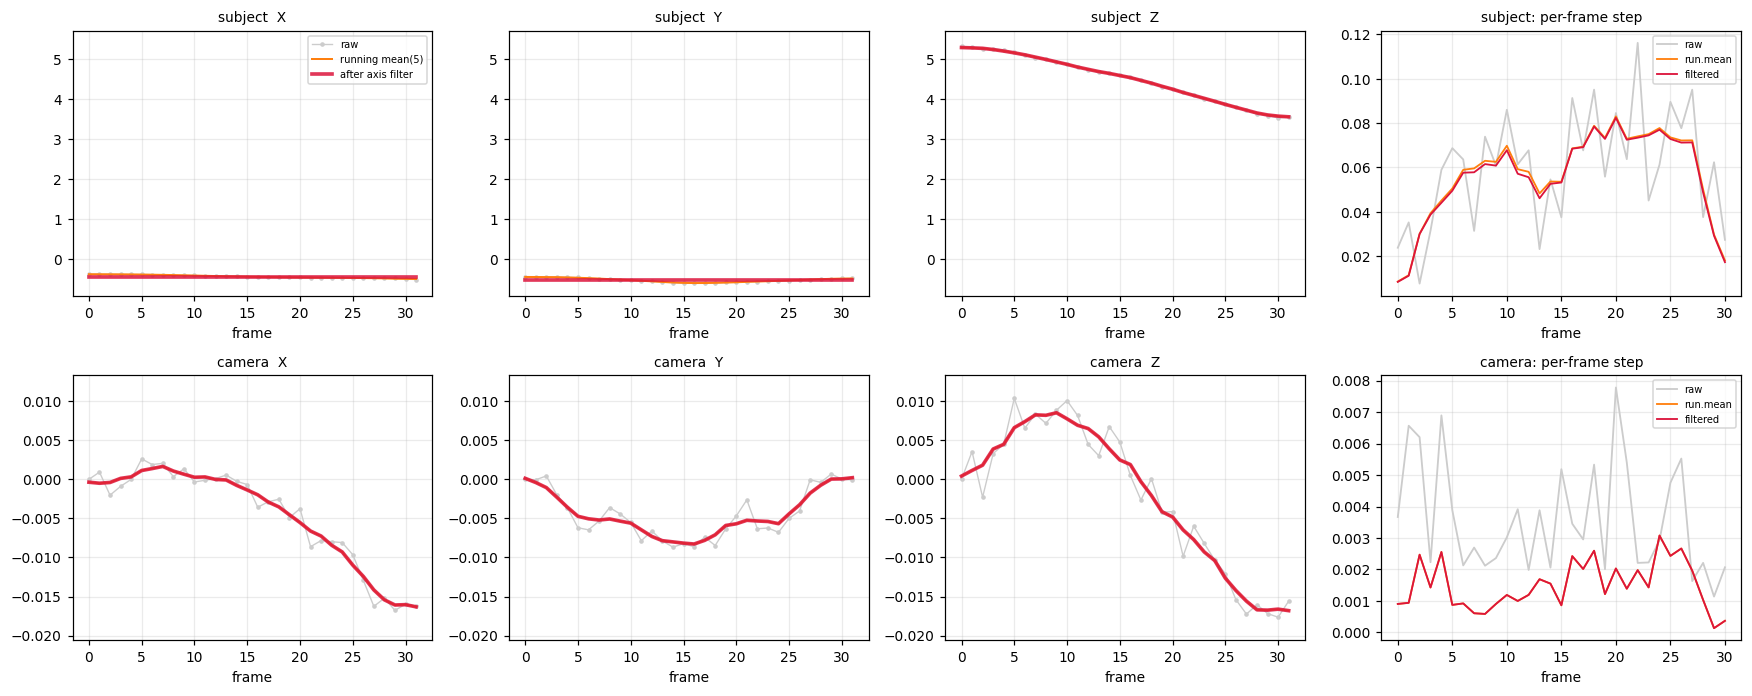


                 raw    savgol  run.mean  filtered   (path length)
subject       1.8565    1.8070    1.7604    1.7316
camera        0.1104    0.0554    0.0464    0.0464

The box average shortens the path more than savgol -- it flattens real turning points
along with the noise.  Whether that matters is what the next cell measures.

                 raw    savgol  run.mean   (displacement start->end)
subject       1.7678    1.7740    1.7361    first-frame shift: savgol 0.0087, run.mean 0.0271
camera        0.0225    0.0226    0.0235    first-frame shift: savgol 0.0005, run.mean 0.0006

Watch the first-frame shift.  A centred box average has no data before frame 0, so its
window is one-sided there and the endpoint is dragged toward the interior -- on a trajectory
that keeps moving one way, both ends get pulled in and the displacement shrinks.  savgol
(mode='interp') fits a polynomial through the edge instead and stays put.  If you report
displacement or start/end positions, this bias lan

In [26]:
# Subject and camera, through the same two operations.
subj_raw    = agg["ransac_median"]
subj_rm     = running_mean(subj_raw, window=5)
cam_rm      = running_mean(cam_track, window=5)

print("axis filtering")
subj_filt, subj_span, subj_keep = filter_axes(subj_rm, raw=subj_raw, label="subject")
cam_filt,  cam_span,  cam_keep  = filter_axes(cam_rm,  raw=cam_track, label="camera")

fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
for r, (rawt, savt, rmt, filt, nm) in enumerate([
        (subj_raw,  smoothed,   subj_rm, subj_filt, "subject"),
        (cam_track, cam_smooth, cam_rm,  cam_filt,  "camera")]):
    for k in range(3):
        ax = axes[r, k]
        ax.plot(rawt[:, k], lw=0.9, color="#cccccc", marker=".", ms=4, label="raw")
        # ax.plot(savt[:, k], lw=1.3, color="#1f77b4", label="savgol(7,2)")   # commented out --
        # savgol is still computed in step 6 (the step 8 verification needs it), just not drawn.
        ax.plot(rmt[:, k],  lw=1.3, color="#ff7f0e", label="running mean(5)")
        ax.plot(filt[:, k], lw=2.4, color="crimson", alpha=0.85, label="after axis filter")
        ax.set_title(f"{nm}  {'XYZ'[k]}", fontsize=9); ax.set_xlabel("frame")
        if r == 0 and k == 0: ax.legend(fontsize=6.5)
    lock_axes(axes[r, :3])                # within the row: subject and camera differ ~100x in
    ax = axes[r, 3]                       # magnitude, so locking across rows would flatten one
    for t_, c_, l_ in [(rawt, "#cccccc", "raw"),
                       (rmt, "#ff7f0e", "run.mean"), (filt, "crimson", "filtered")]:
        ax.plot(np.linalg.norm(np.diff(t_, axis=0), axis=1), color=c_, lw=1.2, label=l_)
    ax.set_title(f"{nm}: per-frame step", fontsize=9); ax.set_xlabel("frame"); ax.legend(fontsize=6.5)
plt.tight_layout(); plt.show()

def plen(t_):
    d = np.diff(t_, axis=0); d = d[np.isfinite(d).all(axis=1)]
    return float(np.linalg.norm(d, axis=1).sum())

print(f"\n{'':10s} {'raw':>9s} {'savgol':>9s} {'run.mean':>9s} {'filtered':>9s}   (path length)")
for nm, a, b, c_, d_ in [("subject", subj_raw, smoothed, subj_rm, subj_filt),
                         ("camera",  cam_track, cam_smooth, cam_rm, cam_filt)]:
    print(f"{nm:10s} {plen(a):9.4f} {plen(b):9.4f} {plen(c_):9.4f} {plen(d_):9.4f}")
print("\nThe box average shortens the path more than savgol -- it flattens real turning points")
print("along with the noise.  Whether that matters is what the next cell measures.")

def ends(t_):
    f = t_[np.isfinite(t_).all(axis=1)]
    return f[0], f[-1], float(np.linalg.norm(f[-1] - f[0]))

print(f"\n{'':10s} {'raw':>9s} {'savgol':>9s} {'run.mean':>9s}   (displacement start->end)")
for nm, a, b, c_ in [("subject", subj_raw, smoothed, subj_rm),
                     ("camera",  cam_track, cam_smooth, cam_rm)]:
    print(f"{nm:10s} {ends(a)[2]:9.4f} {ends(b)[2]:9.4f} {ends(c_)[2]:9.4f}"
          f"    first-frame shift: savgol {np.linalg.norm(ends(b)[0]-ends(a)[0]):.4f}, "
          f"run.mean {np.linalg.norm(ends(c_)[0]-ends(a)[0]):.4f}")
print("\nWatch the first-frame shift.  A centred box average has no data before frame 0, so its")
print("window is one-sided there and the endpoint is dragged toward the interior -- on a trajectory")
print("that keeps moving one way, both ends get pulled in and the displacement shrinks.  savgol")
print("(mode='interp') fits a polynomial through the edge instead and stays put.  If you report")
print("displacement or start/end positions, this bias lands directly on the number you report.")

### Is the running mean good enough to replace savgol?

Two separate questions — what each filter *costs*, and what each filter *does to the signal*. The
cell below measures both rather than assuming.

On cost, the thing to notice is that both filters are the same kind of object: a short symmetric
FIR convolution. Savitzky–Golay is not an optimiser or a fit performed at runtime — the polynomial
least-squares problem is solved once, symbolically, and collapses into a fixed set of taps. For
window 7, order 2 those taps are exactly $\frac{1}{21}[-2, 3, 6, 7, 6, 3, -2]$. A 5-frame running
mean is $\frac{1}{5}[1, 1, 1, 1, 1]$. Same complexity class, $O(n \cdot w)$, two convolutions of
nearly the same length. Any speed difference between them is implementation, not algorithm.

On quality, three numbers matter, and they trade against each other:

* **jerk reduction** — how much frame-to-frame incoherence the filter removed. Higher is smoother.
* **deviation from raw** — how far it moved the data. A filter can always win on jerk by
  flattening everything, so this is the price paid.
* **endpoint bias** — how far the first frame moved. Endpoints have no neighbours on one side, and
  the two filters handle that very differently.

The filter to prefer is the one that buys the most jerk reduction for the least deviation, without
wrecking the endpoints.

In [27]:
import timeit
from scipy.signal import savgol_coeffs
from scipy.ndimage import uniform_filter1d

print("the two filters, as taps")
print(f"  savgol(7, 2)      {np.round(savgol_coeffs(7, 2), 4)}   = 1/21 x {np.round(savgol_coeffs(7,2)*21, 1)}")
print(f"  running mean(5)   {np.round(np.ones(5) / 5, 4)}                             = 1/5  x [1 1 1 1 1]")
print("  -> both are short symmetric FIR filters; savgol's taps just are not all equal.\n")

def rm_fast(track, window=5):
    """The running mean as a real convolution instead of a Python loop."""
    return uniform_filter1d(np.asarray(track, float), window, axis=0, mode="nearest")

bench = np.ascontiguousarray(subj_raw)
print(f"cost, per {T}-frame track (mean of 2000 runs)")
for nm, fn in [("savgol(7,2), scipy",           lambda: savgol_filter(bench, 7, 2, axis=0, mode="interp")),
               ("running mean, python loop",    lambda: running_mean(bench, 5)),
               ("running mean, uniform_filter", lambda: rm_fast(bench, 5))]:
    us = timeit.timeit(fn, number=2000) / 2000 * 1e6
    print(f"  {nm:30s} {us:9.1f} us")
print("  -> the honest comparison is savgol vs uniform_filter1d.  The loop above is written for")
print("     readability (and to shrink the window at the edges); it is not the fast way.\n")

def quality(raw, filt):
    d2 = np.diff(filt, n=2, axis=0); d2 = d2[np.isfinite(d2).all(axis=1)]
    r2 = np.diff(raw,  n=2, axis=0); r2 = r2[np.isfinite(r2).all(axis=1)]
    jerk_f = float(np.sqrt((d2 ** 2).sum(1).mean())); jerk_r = float(np.sqrt((r2 ** 2).sum(1).mean()))
    dev = filt - raw; dev = dev[np.isfinite(dev).all(axis=1)]
    fr = raw[np.isfinite(raw).all(axis=1)]; ff = filt[np.isfinite(filt).all(axis=1)]
    return (100 * (1 - jerk_f / jerk_r),
            float(np.sqrt((dev ** 2).sum(1).mean())),
            float(np.linalg.norm(ff[0] - fr[0])),
            float(np.linalg.norm(ff[-1] - fr[-1])))

print(f"{'':28s} {'jerk drop':>10s} {'deviation':>10s} {'1st frame':>10s} {'last frame':>11s}")
for nm, raw_, f_ in [("subject  savgol(7,2)",   subj_raw,  smoothed),
                     ("subject  running mean",  subj_raw,  subj_rm),
                     ("camera   savgol(7,2)",   cam_track, cam_smooth),
                     ("camera   running mean",  cam_track, cam_rm)]:
    j, dv, e0, e1 = quality(raw_, f_)
    print(f"{nm:28s} {j:9.1f}% {dv:10.4f} {e0:10.4f} {e1:11.4f}")
print("\nRead 'deviation' as the price of the jerk drop, and the endpoint columns as where the")
print("running mean pays for its simplicity: with no data before frame 0 its window goes one-sided")
print("and drags the ends inward, while savgol's mode='interp' fits a polynomial through the edge.")

the two filters, as taps
  savgol(7, 2)      [-0.0952  0.1429  0.2857  0.3333  0.2857  0.1429 -0.0952]   = 1/21 x [-2.  3.  6.  7.  6.  3. -2.]
  running mean(5)   [0.2 0.2 0.2 0.2 0.2]                             = 1/5  x [1 1 1 1 1]
  -> both are short symmetric FIR filters; savgol's taps just are not all equal.

cost, per 32-frame track (mean of 2000 runs)


  savgol(7,2), scipy                 844.7 us


  running mean, python loop         1263.1 us
  running mean, uniform_filter        38.0 us
  -> the honest comparison is savgol vs uniform_filter1d.  The loop above is written for
     readability (and to shrink the window at the edges); it is not the fast way.

                              jerk drop  deviation  1st frame  last frame
subject  savgol(7,2)              66.5%     0.0105     0.0087      0.0147
subject  running mean             74.0%     0.0168     0.0271      0.0144
camera   savgol(7,2)              76.0%     0.0018     0.0005      0.0006
camera   running mean             82.7%     0.0023     0.0006      0.0012

Read 'deviation' as the price of the jerk drop, and the endpoint columns as where the
running mean pays for its simplicity: with no data before frame 0 its window goes one-sided
and drags the ends inward, while savgol's mode='interp' fits a polynomial through the edge.


### Is an axis-aligned test the right test?

Flattening an axis only makes sense if the motion actually runs along the coordinate axes. The
camera frame's X/Y/Z were fixed by where the camera happened to be pointing at `t=0`; the subject
did not agree to walk along any of them. If someone moves diagonally — say 45° between X and Z —
then both axes carry a large share, neither gets flattened, and the test has done nothing even
though the motion is genuinely one-dimensional.

The check below is PCA on the trajectory. If the first component holds nearly all the variance the
motion *is* essentially 1-D, and the listed angles say whether that direction is close enough to a
coordinate axis for the per-axis test to be the right tool.

In [28]:
for nm, t_ in [("subject", subj_rm), ("camera", cam_rm)]:
    f = t_[np.isfinite(t_).all(axis=1)]
    if len(f) < 3:
        print(f"{nm}: too few frames"); continue
    u, s, vt = np.linalg.svd(f - f.mean(axis=0), full_matrices=False)
    var = s ** 2 / (s ** 2).sum()
    ang = np.degrees(np.arccos(np.clip(np.abs(vt[0]), 0, 1)))     # angle to each coordinate axis
    print(f"{nm:8s} variance along PC1/PC2/PC3 = {var[0]:.3f} / {var[1]:.3f} / {var[2]:.3f}")
    print(f"{'':8s} PC1 direction {np.round(vt[0], 3)}   "
          f"angle to X/Y/Z = {ang[0]:5.1f} / {ang[1]:5.1f} / {ang[2]:5.1f} deg")
    near = "XYZ"[int(np.argmin(ang))]
    print(f"{'':8s} -> dominant direction is {ang.min():.1f} deg off the {near} axis; "
          f"per-axis filtering is {'appropriate' if ang.min() < 25 else 'the WRONG tool here'}\n")

subject  variance along PC1/PC2/PC3 = 0.993 / 0.007 / 0.000
         PC1 direction [-0.066 -0.03  -0.997]   angle to X/Y/Z =  86.2 /  88.3 /   4.1 deg
         -> dominant direction is 4.1 deg off the Z axis; per-axis filtering is appropriate

camera   variance along PC1/PC2/PC3 = 0.948 / 0.044 / 0.008
         PC1 direction [-0.556  0.135 -0.82 ]   angle to X/Y/Z =  56.2 /  82.2 /  34.9 deg
         -> dominant direction is 34.9 deg off the Z axis; per-axis filtering is the WRONG tool here



## Step 8 — the finished trajectory

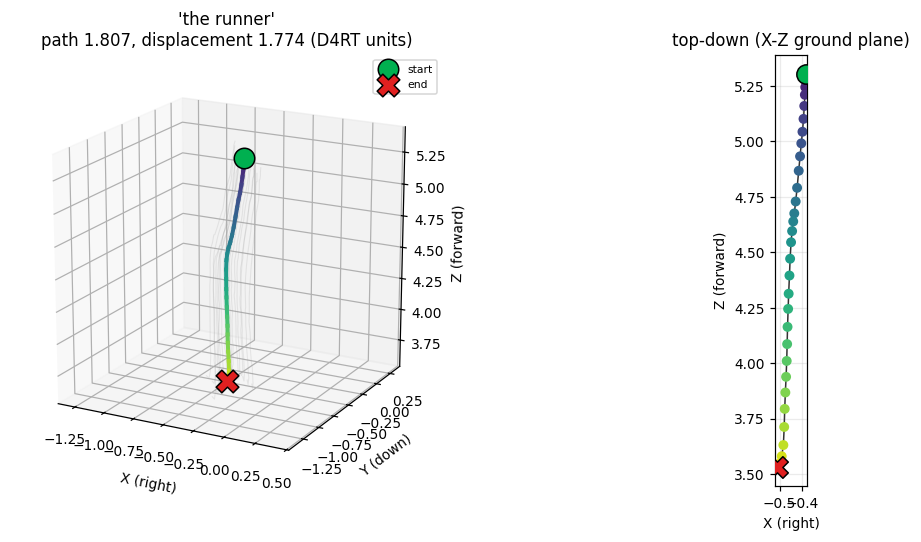

In [29]:
finite = np.isfinite(smoothed).all(axis=1)
idx = np.flatnonzero(finite)
path_len = float(np.linalg.norm(np.diff(smoothed[finite], axis=0), axis=1).sum())
displacement = float(np.linalg.norm(smoothed[finite][-1] - smoothed[finite][0]))

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
for p in range(P):                                  # the spread the aggregate summarises
    if not keep[p]: continue
    ok = np.isfinite(masked[p]).all(axis=1)
    if ok.sum() > 1: ax.plot(*masked[p, ok].T, color="#999999", alpha=0.18, lw=0.7)
cm = plt.get_cmap("viridis")
for a, b in zip(idx[:-1], idx[1:]):
    ax.plot(*smoothed[[a, b]].T, color=cm(a / max(T - 1, 1)), lw=2.6)
ax.scatter(*smoothed[idx[0]],  s=180, c="#00b050", edgecolors="black", zorder=6, label="start")
ax.scatter(*smoothed[idx[-1]], s=220, c="#e02020", marker="X", edgecolors="black", zorder=6, label="end")
ax.set_xlabel("X (right)"); ax.set_ylabel("Y (down)"); ax.set_zlabel("Z (forward)")
ax.set_title(f"{summary['subject']!r}\npath {path_len:.3f}, displacement {displacement:.3f} (D4RT units)")
ax.view_init(elev=18, azim=-62); ax.legend(fontsize=7)
equalise_3d(ax, smoothed[finite])

ax = fig.add_subplot(1, 2, 2)                        # top-down: the readable view of "where it went"
ax.plot(smoothed[finite, 0], smoothed[finite, 2], color="#333333", lw=1.0)
ax.scatter(smoothed[finite, 0], smoothed[finite, 2], c=idx, cmap="viridis", s=30, zorder=3)
ax.scatter(*smoothed[idx[0]][[0, 2]],  s=160, c="#00b050", edgecolors="black", zorder=4)
ax.scatter(*smoothed[idx[-1]][[0, 2]], s=200, c="#e02020", marker="X", edgecolors="black", zorder=4)
ax.set_xlabel("X (right)"); ax.set_ylabel("Z (forward)"); ax.set_title("top-down (X-Z ground plane)")
ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### Does the rebuild match the pipeline?

Every array above was recomputed from the raw `.npz` files. The pipeline's own results are sitting
in `analysis/trajectory.npz` and `analysis/camera_poses.npz`, so the two should agree to floating
point — including the RANSAC fits, because `ransac_rigid` draws its samples in the same order with
the same `seed=t`. Any non-zero difference here means the notebook drifted from the source.

In [30]:
ref_traj = np.load(VD / "analysis" / "trajectory.npz")
ref_cam  = np.load(VD / "analysis" / "camera_poses.npz")

def diff(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    both_nan = np.isnan(a) & np.isnan(b)
    d = np.abs(np.where(both_nan, 0.0, a - b))
    return float(np.nanmax(d)) if d.size else 0.0

checks = [("valid",           valid,                 ref_traj["valid"]),
          ("keep",            keep,                  ref_traj["keep"]),
          ("mean",            agg["mean"],           ref_traj["mean"]),
          ("median",          agg["median"],         ref_traj["median"]),
          ("ransac_median",   agg["ransac_median"],  ref_traj["ransac_median"]),
          ("smoothed",        smoothed,              ref_traj["smoothed"]),
          ("n_inliers",       agg["n_inliers"],      ref_traj["n_inliers"]),
          ("camera rotation", rot,                   ref_cam["rotation"]),
          ("camera transl.",  trans,                 ref_cam["translation"]),
          ("camera rmse",     rmse,                  ref_cam["rmse"]),
          ("camera inliers",  ninl,                  ref_cam["inlier_counts"])]

print(f"{'array':18s} {'max |difference|':>18s}")
for name, mine, theirs in checks:
    print(f"{name:18s} {diff(mine, theirs):18.3e}   {'OK' if diff(mine, theirs) < 1e-9 else 'MISMATCH'}")

print(f"\npipeline summary says: kept {summary['tracks_kept']}/{summary['tracks_total']} tracks, "
      f"path length {summary['trajectory_path_length']:.4f}")
print(f"this notebook  says: kept {keep.sum()}/{P} tracks, path length {path_len:.4f}")
if summary["warnings"]:
    print("\nwarnings recorded by the pipeline:")
    for w in summary["warnings"]: print("  -", w)

array                max |difference|
valid                       0.000e+00   OK
keep                        0.000e+00   OK
mean                        0.000e+00   OK
median                      0.000e+00   OK
ransac_median               0.000e+00   OK
smoothed                    0.000e+00   OK
n_inliers                   0.000e+00   OK
camera rotation             0.000e+00   OK
camera transl.              0.000e+00   OK
camera rmse                 0.000e+00   OK
camera inliers              0.000e+00   OK

pipeline summary says: kept 19/20 tracks, path length 1.8070
this notebook  says: kept 19/20 tracks, path length 1.8070


## Step 9 — how far is the subject from the camera?

Everything needed for this already exists, and it exists in a *comparable* form, which is the part
worth pausing on. The subject trajectory was queried with `t_cam=0` fixed, so all 32 positions are
expressed in frame-0 camera coordinates. Step 3 recovered each camera's pose in those same frame-0
coordinates. Two different queries, one shared frame — so they can simply be subtracted:

$$\mathbf{r}(t) = \mathbf{p}_{\text{subject}}(t) - \mathbf{c}_{\text{camera}}(t)$$

Three views of that vector, because they answer different questions:

* **‖r(t)‖** — the scalar separation. Is the subject approaching or receding?
* **components in frame-0 axes** — a fixed reference, so "the gap grew mostly in Z" is meaningful
  across the whole clip.
* **the two paths drawn together, one coordinate at a time**, each plotted as *change from the
  first frame* — the subject's line and the camera's line both start at zero, and the shaded band
  between them is how much the separation has changed since frame 0. Plotting the raw positions
  instead would put a constant offset of several units in the Z panel and flatten everything
  happening inside it; the starting gap is printed in each title so nothing is lost. Which line
  moves tells you which of the two is responsible.

Two things to keep in mind. These are D4RT units, not metres — the training loss normalises by mean
depth, so no absolute scale is recoverable. And this uses the **running-mean** trajectories, not
the axis-filtered ones: flattening an axis to its median would corrupt the separation vector by
construction, since a suppressed axis contributes a constant offset rather than its real value.

sanity: at t=0 the camera sits at the origin, so the separation must equal |subject(0)|
        |r(0)| = 5.3443   |subject(0)| = 5.3443   difference 0.00e+00



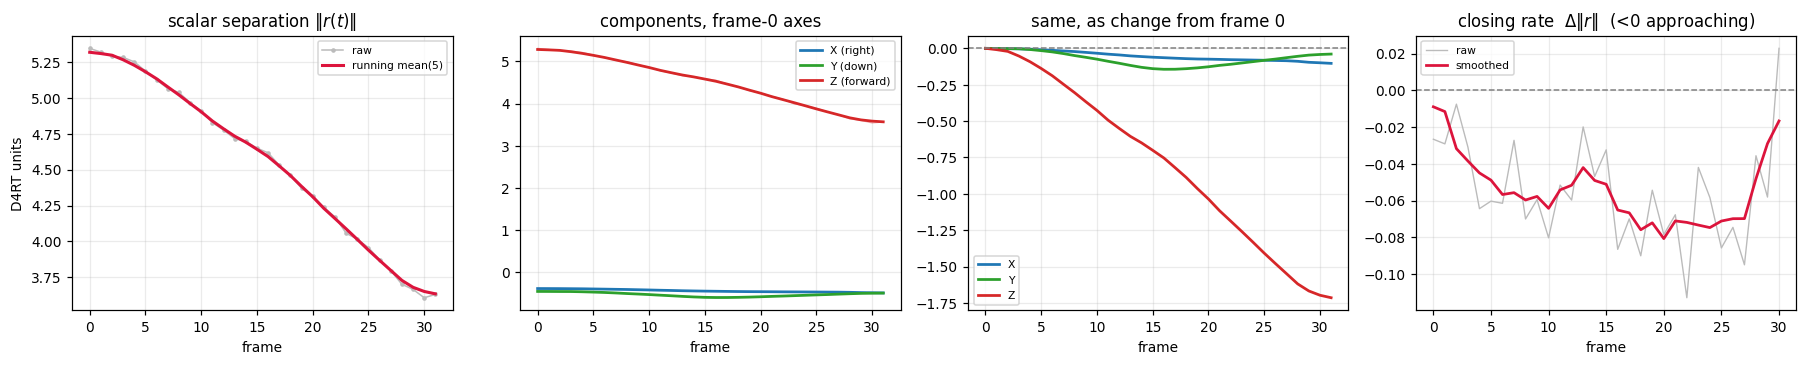

separation   start  5.3169   end  3.6355   net -1.6814  (-31.6%)
             min    3.6355 (frame 31)   max  5.3169 (frame 0)
             range  1.6814   = 31.6% of the starting distance

how much of the change is the subject moving vs the camera moving:
  subject path  1.7604   camera path  0.0464


In [31]:
# frame-0 coordinates throughout; smoothed inputs, with the raw pair kept for comparison.
sep_raw    = agg["ransac_median"] - cam_track
sep_smooth = subj_rm - cam_rm
dist_raw, dist_smooth = np.linalg.norm(sep_raw, axis=1), np.linalg.norm(sep_smooth, axis=1)

print(f"sanity: at t=0 the camera sits at the origin, so the separation must equal |subject(0)|")
print(f"        |r(0)| = {dist_raw[0]:.4f}   |subject(0)| = {np.linalg.norm(agg['ransac_median'][0]):.4f}"
      f"   difference {abs(dist_raw[0] - np.linalg.norm(agg['ransac_median'][0])):.2e}\n")

fig, axes = plt.subplots(1, 4, figsize=(16.5, 3.4))

ax = axes[0]
ax.plot(dist_raw, lw=1.0, color="#bbbbbb", marker=".", ms=4, label="raw")
ax.plot(dist_smooth, lw=2.0, color="crimson", label="running mean(5)")
ax.set_xlabel("frame"); ax.set_ylabel("D4RT units")
ax.set_title(r"scalar separation $\|r(t)\|$"); ax.legend(fontsize=7)

ax = axes[1]
for k, (nm, col) in enumerate([("X (right)", "#1f77b4"), ("Y (down)", "#2ca02c"), ("Z (forward)", "#d62728")]):
    ax.plot(sep_raw[:, k], lw=0.8, color=col, alpha=0.35)
    ax.plot(sep_smooth[:, k], lw=1.8, color=col, label=nm)
ax.set_xlabel("frame"); ax.set_title("components, frame-0 axes"); ax.legend(fontsize=7)

ax = axes[2]
for k, (nm, col) in enumerate([("X", "#1f77b4"), ("Y", "#2ca02c"), ("Z", "#d62728")]):
    ax.plot(sep_smooth[:, k] - sep_smooth[0, k], lw=1.8, color=col, label=nm)
ax.axhline(0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_title("same, as change from frame 0"); ax.legend(fontsize=7)

ax = axes[3]
ax.plot(np.diff(dist_raw), lw=0.9, color="#bbbbbb", label="raw")
ax.plot(np.diff(dist_smooth), lw=1.8, color="crimson", label="smoothed")
ax.axhline(0, ls="--", lw=1, color="grey")
ax.set_xlabel("frame"); ax.set_title("closing rate  $\\Delta\\|r\\|$  (<0 approaching)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

d0, d1 = dist_smooth[0], dist_smooth[-1]
print(f"separation   start {d0:7.4f}   end {d1:7.4f}   net {d1 - d0:+7.4f}  ({100*(d1/d0 - 1):+.1f}%)")
print(f"             min   {dist_smooth.min():7.4f} (frame {int(np.argmin(dist_smooth))})"
      f"   max {dist_smooth.max():7.4f} (frame {int(np.argmax(dist_smooth))})")
print(f"             range {dist_smooth.max() - dist_smooth.min():7.4f}"
      f"   = {(dist_smooth.max() - dist_smooth.min()) / max(d0, 1e-9) * 100:.1f}% of the starting distance")
print(f"\nhow much of the change is the subject moving vs the camera moving:")
print(f"  subject path {np.linalg.norm(np.diff(subj_rm, axis=0), axis=1).sum():7.4f}"
      f"   camera path {np.linalg.norm(np.diff(cam_rm, axis=0), axis=1).sum():7.4f}")

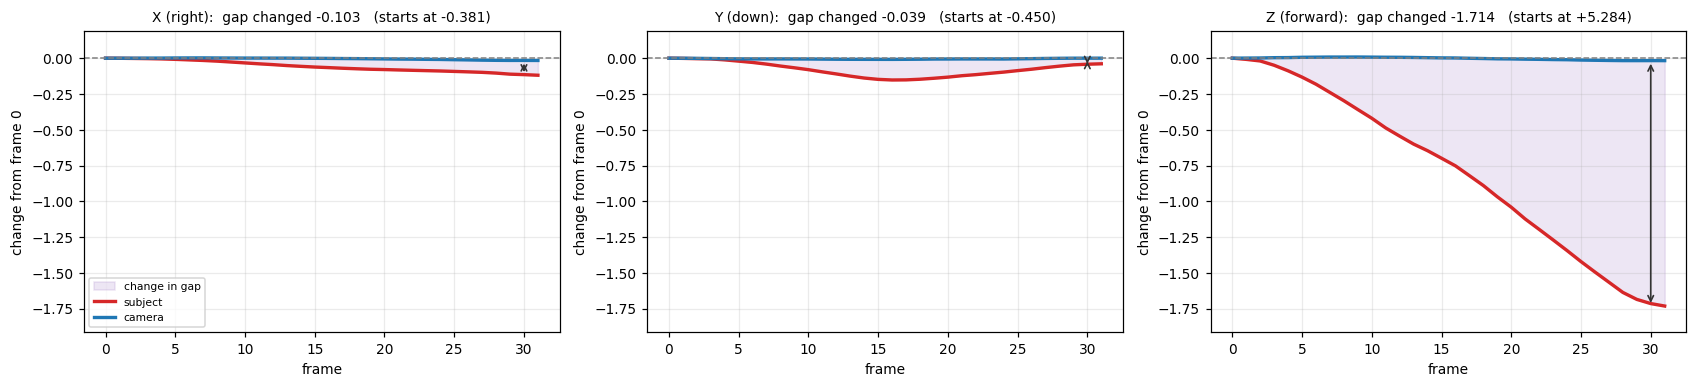

Both curves start at zero, so the shaded band is the CHANGE in separation, not the
separation itself -- the constant offset (printed in each title) has been subtracted out.
Which line moves still tells you who caused the change.

axis     gap t=0  gap t=end    change    subject moved  camera moved   who closed it
X        -0.3812    -0.4845   -0.1033          -0.1192       -0.0159   subject
Y        -0.4495    -0.4889   -0.0394          -0.0393        0.0001   subject
Z         5.2841     3.5697   -1.7144          -1.7316       -0.0172   subject


In [32]:
# One coordinate at a time, as CHANGE from the first frame.  Plotting absolute positions puts
# a constant ~5-unit offset in the Z panel that swamps everything moving inside it; subtracting
# each track's own starting value removes the offset and keeps the shape.
def rel(track):
    """Track minus its own first finite frame, so every curve starts at zero."""
    f = np.flatnonzero(np.isfinite(track).all(axis=1))
    return track - track[f[0]] if len(f) else track.copy()

subj_rel, cam_rel = rel(subj_rm), rel(cam_rm)
frames = np.arange(T)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 3.6))
for k, (nm, direction) in enumerate([("X", "right"), ("Y", "down"), ("Z", "forward")]):
    ax = axes[k]
    ax.fill_between(frames, cam_rel[:, k], subj_rel[:, k], color="#9467bd", alpha=0.16,
                    label="change in gap")
    ax.plot(frames, subj_rel[:, k], lw=2.2, color="#d62728", label="subject")
    ax.plot(frames, cam_rel[:, k],  lw=2.2, color="#1f77b4", label="camera")
    ax.axhline(0, ls="--", lw=1, color="grey")
    dg = (subj_rel[:, k] - cam_rel[:, k])
    ax.annotate("", xy=(T - 2, subj_rel[-1, k]), xytext=(T - 2, cam_rel[-1, k]),
                arrowprops=dict(arrowstyle="<->", color="#333333", lw=1.1))
    ax.set_xlabel("frame"); ax.set_ylabel("change from frame 0")
    ax.set_title(f"{nm} ({direction}):  gap changed {dg[-1]:+.3f}"
                 f"   (starts at {sep_smooth[0, k]:+.3f})", fontsize=9)
    if k == 0: ax.legend(fontsize=7, loc="best")
lock_axes(axes)                           # one scale across X, Y and Z
plt.tight_layout(); plt.show()

print("Both curves start at zero, so the shaded band is the CHANGE in separation, not the")
print("separation itself -- the constant offset (printed in each title) has been subtracted out.")
print("Which line moves still tells you who caused the change.\n")
print(f"{'axis':6s} {'gap t=0':>9s} {'gap t=end':>10s} {'change':>9s}   "
      f"{'subject moved':>14s} {'camera moved':>13s}   who closed it")
for k, nm in enumerate("XYZ"):
    ds, dc = subj_rel[-1, k], cam_rel[-1, k]
    who = "subject" if abs(ds) > 3 * abs(dc) else ("camera" if abs(dc) > 3 * abs(ds) else "both")
    print(f"{nm:6s} {sep_smooth[0, k]:9.4f} {sep_smooth[-1, k]:10.4f} "
          f"{sep_smooth[-1, k]-sep_smooth[0, k]:9.4f}   {ds:14.4f} {dc:13.4f}   {who}")

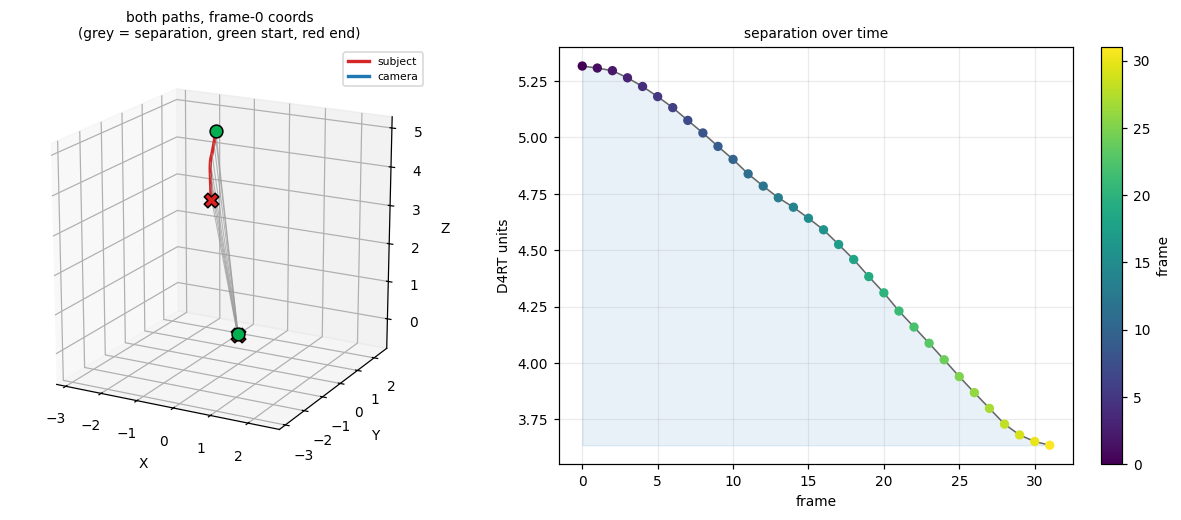

In [33]:
# The two paths in one frame, with the separation drawn at intervals.
fig = plt.figure(figsize=(11.5, 4.8))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*subj_rm.T, color="#d62728", lw=2.2, label="subject")
ax.plot(*cam_rm.T,  color="#1f77b4", lw=2.2, label="camera")
for t in range(0, T, max(1, T // 8)):
    ax.plot(*np.array([cam_rm[t], subj_rm[t]]).T, color="#999999", lw=0.7, alpha=0.7)
ax.scatter(*subj_rm[0],  s=70, c="#00b050", edgecolors="black", zorder=6)
ax.scatter(*subj_rm[-1], s=90, c="#e02020", marker="X", edgecolors="black", zorder=6)
ax.scatter(*cam_rm[0],   s=70, c="#00b050", edgecolors="black", zorder=6)
ax.scatter(*cam_rm[-1],  s=90, c="#e02020", marker="X", edgecolors="black", zorder=6)
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("both paths, frame-0 coords\n(grey = separation, green start, red end)", fontsize=9)
ax.view_init(elev=18, azim=-62); ax.legend(fontsize=7)
equalise_3d(ax, np.vstack([subj_rm, cam_rm]))

ax = fig.add_subplot(1, 2, 2)
sc = ax.scatter(np.arange(T), dist_smooth, c=np.arange(T), cmap="viridis", s=26, zorder=3)
ax.plot(dist_smooth, color="#666666", lw=1.0, zorder=2)
ax.fill_between(np.arange(T), dist_smooth.min(), dist_smooth, color="#1f77b4", alpha=0.10)
ax.set_xlabel("frame"); ax.set_ylabel("D4RT units"); ax.set_title("separation over time", fontsize=9)
fig.colorbar(sc, ax=ax, label="frame", fraction=0.04)
plt.tight_layout(); plt.show()

## Appendix — the other clips, if you want them

Everything above ran on the one clip you selected. This last section is the exception: it wraps
steps 1–6 into a single function and runs it over *every* video in the run directory, so the three
can be compared side by side — how many tracks survive, how much the camera swung, whether the
trajectory is a clean arc or a mess.

It is skipped unless `COMPARE_ALL = True` in the setup cell.

In [34]:
def analyse(slug):
    """Steps 1-6 end to end for one video, returning everything the plots need."""
    vd = RUN_DIR / slug
    subj = dict(np.load(vd / "d4rt" / "subject.npz"))
    cam  = dict(np.load(vd / "d4rt" / "camera.npz"))
    summ = json.loads((vd / "analysis" / "summary.json").read_text())

    x = subj["xyz_3d"].astype(np.float64)
    vis, conf = sigmoid(subj["visibility"]), sigmoid(subj["confidence"])
    v = np.isfinite(x).all(-1) & (vis > VISIBILITY_THRESHOLD) & (conf > CONFIDENCE_THRESHOLD)
    w = conf ** 2
    m = np.where(v[..., None], x, np.nan)
    n_p, n_t = x.shape[:2]

    # step 4
    ctr = np.nanmedian(m, axis=0)
    sc  = cloud_scale(m[np.isfinite(m).all(-1)])
    k   = np.ones(n_p, bool)
    k &= ~(np.nan_to_num(np.nanmedian(np.linalg.norm(m - ctr[None], axis=-1), axis=1), nan=np.inf)
           > MEMBERSHIP_RATIO * sc)
    mr = np.zeros(n_p)
    for lag in LAGS:
        if lag >= n_t: continue
        d = m[:, lag:] - m[:, :-lag]
        mr = np.maximum(mr, np.nan_to_num(
            np.nanmedian(np.linalg.norm(d - np.nanmedian(d, axis=0)[None], axis=-1), axis=1), nan=np.inf))
    rj = mr > MOTION_RATIO * sc
    if k.sum() > 2:
        cut = np.nanmedian(mr[k]) + 3.0 * mad(mr[k])
        if np.isfinite(cut): rj |= mr > cut
    k &= ~rj
    jit = np.nanmedian(np.linalg.norm(m[:, 2:] - 2 * m[:, 1:-1] + m[:, :-2], axis=-1), axis=1)
    if k.sum() > 2:
        cut = np.nanmedian(jit[k]) + 3.0 * mad(jit[k])
        if np.isfinite(cut): k &= ~(np.nan_to_num(jit, nan=np.inf) > cut)

    # step 5 + 6
    med = np.full((n_t, 3), np.nan); ni = np.zeros(n_t, int)
    for tt in range(n_t):
        s = v[:, tt] & np.isfinite(x[:, tt]).all(-1) & k
        ni[tt] = s.sum()
        if s.any(): med[tt] = geometric_median(x[s, tt], w[s, tt])
    sm = smooth_trajectory(med)

    # step 3 (camera), for the rotation number only
    cw = np.where(sigmoid(cam["visibility"]) > VISIBILITY_THRESHOLD, sigmoid(cam["confidence"]) ** 2, 0.0)
    cx = cam["xyz_3d"].astype(np.float64)
    Rs = np.tile(np.eye(3), (cx.shape[0], 1, 1))
    for tt in range(1, cx.shape[0]):
        f = ransac_rigid(cx[tt], cx[0], weights=np.minimum(cw[tt], cw[0]), seed=tt)
        if f is not None: Rs[tt] = f["rotation"]
    tot = sum(rotation_angle(Rs[i] @ Rs[i-1].T) for i in range(1, len(Rs)))

    return dict(slug=slug, subject=summ["subject"], masked=m, keep=k, smoothed=sm,
                n_inliers=ni, scale=sc, camera_rotation_deg=tot, summary=summ)

results = [analyse(s) for s in VIDEOS] if COMPARE_ALL else []
if not results:
    print("skipped -- set COMPARE_ALL = True in the setup cell to run this")
for r in results:
    fin = np.isfinite(r["smoothed"]).all(axis=1)
    print(f"{r['subject']!r:36s} kept {r['keep'].sum():2d}/{len(r['keep'])} tracks   "
          f"scale {r['scale']:.3f}   camera swing {r['camera_rotation_deg']:6.2f} deg   "
          f"path {np.linalg.norm(np.diff(r['smoothed'][fin], axis=0), axis=1).sum():.3f}")

skipped -- set COMPARE_ALL = True in the setup cell to run this


In [35]:
fig = plt.figure(figsize=(15, 4.8)) if results else None
for i, r in enumerate(results):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    for p in range(r["masked"].shape[0]):
        if not r["keep"][p]: continue
        ok = np.isfinite(r["masked"][p]).all(axis=1)
        if ok.sum() > 1: ax.plot(*r["masked"][p, ok].T, color="#999999", alpha=0.18, lw=0.7)
    tr = r["smoothed"]; fin = np.isfinite(tr).all(axis=1); ii = np.flatnonzero(fin)
    for a, b in zip(ii[:-1], ii[1:]):
        ax.plot(*tr[[a, b]].T, color=plt.get_cmap("viridis")(a / max(len(tr) - 1, 1)), lw=2.4)
    ax.scatter(*tr[ii[0]],  s=140, c="#00b050", edgecolors="black", zorder=6)
    ax.scatter(*tr[ii[-1]], s=170, c="#e02020", marker="X", edgecolors="black", zorder=6)
    ax.set_title(f"{r['subject']!r}\nkept {r['keep'].sum()}/{len(r['keep'])}, "
                 f"camera {r['camera_rotation_deg']:.1f} deg", fontsize=9)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z"); ax.view_init(elev=18, azim=-62)
    equalise_3d(ax, tr[fin])
if results:
    fig.suptitle("green = start, red X = end, colour along the path = time", y=1.02)
    plt.tight_layout(); plt.show()
else:
    plt.close(fig) if fig else None

## What to distrust

Three failure modes this walk-through makes visible, in the order they bite:

1. **SAM3 picked the wrong instance.** Step 0's candidate view is the only place this is
   catchable — nothing downstream can detect that the trajectory belongs to the wrong person.
2. **Too few tracks survive step 4.** Under ~6 of 20, the problem is almost always the seeding
   frame, not the individual points; the pipeline emits a warning for this.
3. **Camera alignment rmse above ~5% of scene scale (step 3).** D4RT's cross-`t_cam` consistency is
   the limiting factor, and the recovered rotation feeds the orientation stage — so a bad fit
   silently mis-rotates every facing direction.

Units are arbitrary throughout: path length and displacement are only comparable *within* a clip.